# Generador de exámenes médicos — el proyecto completo

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ErnestoSCL/generador-examenes-medicos/blob/main/notebooks/00_proyecto_completo_colab.ipynb)

Un modelo de 4.000 millones de parámetros, afinado con LoRA, que genera preguntas
de opción múltiple en español a partir del corpus MedQuAD de los Institutos
Nacionales de Salud de EE. UU. Este notebook reúne los cinco del proyecto en un
solo recorrido:

| Parte | Qué hace | Notebook original |
|---|---|---|
| 1 | Limpieza del corpus: de 47,441 a 14,528 filas | 01 |
| 2 | Fragmentación y dataset sintético generado por `gpt-4o-mini` | 02 |
| 3 | Barrido de 6 configuraciones de LoRA y entrenamiento final | 03 |
| 4 | Barrido de parámetros de generación | 04 |
| 5 | El afinado contra el modelo base con cuatro prompts | 05 |

## Se puede leer sin ejecutarlo

**Las salidas que ves están guardadas.** Provienen de la ejecución completa de
los notebooks 01 a 05 en una RTX 5070 Ti de 16 GB. El código es el mismo, con
tres añadidos: la preparación del entorno (abajo), el cambio automático a
float16 en GPUs sin bfloat16, y el modo de prueba rápida.

Algunas salidas mencionan rutas locales (`D:\...`): son de esa ejecución. La
celda del entrenamiento final muestra que se reanudó desde un checkpoint porque
el entrenamiento ya había terminado antes (48 minutos). Si ejecutas el notebook,
todas las salidas se reemplazan por las de tu corrida.

## Cómo ejecutarlo en Colab

1. **Entorno de ejecución → Cambiar tipo de entorno → GPU.** La T4 gratuita
   alcanza para la prueba rápida; para reproducir todo conviene una L4 o A100.
2. **Opcional:** un secreto `OPENAI_API_KEY` (icono de la llave, a la
   izquierda) y `USAR_API = True` para volver a correr los jueces de `gpt-4o`.
3. Revisa la configuración y usa **Entorno de ejecución → Ejecutar todas**.

El repositorio es público: Colab lo clona sin credenciales.

| Configuración | Qué hace | Tiempo | API |
|---|---|---|---|
| `PRUEBA_RAPIDA = True` *(por defecto)* | recorta datos, pasos y casos: comprueba que todo corre | minutos | nada |
| `PRUEBA_RAPIDA = False` | reproduce el proyecto completo | ~4 h en la RTX 5070 Ti; más en Colab | nada |
| `USAR_API = True` | además vuelve a correr los jueces | — | ~USD 0.3 en prueba, ~USD 3 completo |

**Con `USAR_API = False` no se llama a la API.** El dataset se reconstruye con
las 5,250 respuestas originales de `gpt-4o-mini`, guardadas en
`data/mcq_crudo.jsonl`, así que es el mismo dataset con el que se entrenó. Las
celdas de los jueces se omiten y lo avisan.

La aplicación Streamlit no se ejecuta aquí. Al terminar la parte 3, el
adaptador queda comprimido en `/content/adapter.zip`: descomprimido en
`app/adapter/`, la aplicación lo usa en local.


## Configuración


In [ ]:
PRUEBA_RAPIDA = True   # True: recorta todo para comprobar que corre. False: reproduce completo (horas).
USAR_API = False       # True: vuelve a correr los jueces de gpt-4o (necesita el secreto OPENAI_API_KEY).


## Preparación del entorno

Clona el repositorio y se ubica en `notebooks/`, de modo que todas las rutas del
proyecto (`../data`, `../app/adapter`) funcionan igual que en local. En local
hace lo mismo sobre un clon temporal: así una prueba no pisa los datos ni el
adaptador del proyecto.


In [ ]:
import os, shutil, subprocess, sys, tempfile
from pathlib import Path

EN_COLAB = "google.colab" in sys.modules
REPO = "github.com/ErnestoSCL/generador-examenes-medicos.git"


def secreto(nombre):
    """Lee un secreto de Colab; None si no existe o no se autorizo."""
    try:
        from google.colab import userdata
        return userdata.get(nombre)
    except Exception:
        return None


if EN_COLAB:
    TRABAJO = Path("/content/generador-examenes-medicos")
    if not TRABAJO.exists():
        token = secreto("GITHUB_TOKEN")
        url = f"https://{token}@{REPO}" if token else f"https://{REPO}"
        r = subprocess.run(["git", "clone", "-q", "--depth", "1", url, str(TRABAJO)],
                           capture_output=True, text=True)
        if r.returncode != 0:
            raise RuntimeError("No se pudo clonar el repositorio. Si es privado, agrega el "
                               "secreto GITHUB_TOKEN y autoriza su uso en este notebook.")
    # Solo la pila de Hugging Face: torch, numpy y pandas quedan los de Colab,
    # para no obligar a reiniciar el entorno.
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U", "transformers>=5",
                    "peft", "accelerate", "datasets", "langchain-text-splitters",
                    "openai", "python-dotenv"], check=True)
    if secreto("OPENAI_API_KEY"):
        os.environ["OPENAI_API_KEY"] = secreto("OPENAI_API_KEY")
else:
    RAIZ = Path.cwd().parent
    from dotenv import load_dotenv
    load_dotenv(RAIZ / ".env")
    TRABAJO = Path(tempfile.gettempdir()) / "generador_examenes_trabajo"
    shutil.rmtree(TRABAJO, ignore_errors=True)
    subprocess.run(["git", "clone", "-q", str(RAIZ), str(TRABAJO)], check=True)

os.chdir(TRABAJO / "notebooks")
HAY_API = (USAR_API and bool(os.environ.get("OPENAI_API_KEY"))
           and os.environ.get("FORZAR_SIN_API") != "1")
os.environ["PRUEBA_RAPIDA"] = "1" if PRUEBA_RAPIDA else "0"
print("entorno:", "Colab" if EN_COLAB else "local", "| trabajando en:", TRABAJO)
print("modo:", "prueba rapida" if PRUEBA_RAPIDA else "completo")
print("API de OpenAI:", "si" if HAY_API else "no: el dataset sale de la cache y los jueces se omiten")


In [ ]:
import torch

assert torch.cuda.is_available(), ("Hace falta GPU. En Colab: Entorno de ejecucion > "
                                   "Cambiar tipo de entorno > GPU.")
# bfloat16 necesita una GPU Ampere o posterior (L4, A100, RTX 30xx en adelante).
# La T4 gratuita de Colab no lo tiene: ahi se trabaja en float16.
BF16 = (torch.cuda.get_device_capability(0)[0] >= 8
        and os.environ.get("FORZAR_FP16") != "1")
DTYPE = torch.bfloat16 if BF16 else torch.float16
props = torch.cuda.get_device_properties(0)
print(f"GPU: {props.name} | {props.total_memory/1e9:.0f} GB | "
      f"precision: {'bfloat16' if BF16 else 'float16'}")


In [ ]:
# Las celdas que llaman a la API empiezan con %%con_api: si no hay API, se
# omiten con un aviso en vez de fallar, y la ejecucion sigue.
from IPython.core.magic import register_cell_magic


@register_cell_magic
def con_api(linea, celda):
    if HAY_API:
        get_ipython().run_cell(celda).raise_error()
    else:
        print("[sin API] celda omitida: la salida guardada es la de la ejecucion original")


# Parte 1 — Limpieza del corpus MedQuAD

*Notebook original: `01_limpieza.ipynb`.*


# 01 — Limpieza de MedQuAD

Heredado del Proyecto Integrador de RAG medico, donde ya estaba validado. Once pasos sobre `HoangHa/MedQuaD` que dejan el corpus listo para fragmentar.

**Tres cambios respecto del original:**

1. Se conserva la columna `category` (el original la descartaba). Es una dimension mas para el selector de temas de la aplicacion.
2. Los splits del paso 11 no se usan en este proyecto: aqui hacen falta splits a nivel de chunk y agrupados por documento, que construye el notebook 02.
3. La salida que importa es `medqa_clean.parquet`, el **corpus completo**. El proyecto anterior fragmentaba solo el split de entrenamiento; aqui la app debe poder generar preguntas de cualquier tema.

**Salida:** `data/medqa_clean.parquet`


# 01 — Data Preparation and Cleaning

## Ficha técnica del sistema

| Campo | Detalle |
|---|---|
| **Dominio** | Preguntas y respuestas médicas orientadas a pacientes. |
| **Objetivo** | Construir un asistente RAG que responda preguntas médicas fundamentándose en MedQuAD y conserve trazabilidad de fuente. |
| **Corpus** | `HoangHa/MedQuaD` vía Hugging Face `datasets`. |
| **Embeddings** | `sentence-transformers/all-mpnet-base-v2` (768 dimensiones). |
| **LLM** | `Qwen/Qwen2.5-7B-Instruct`, cuantizado en 4-bit NF4. |
| **Retrieval** | FAISS Flat IP, FAISS HNSW, BM25 híbrido y reranker Cross-Encoder. |
| **Evaluación** | Grounding, Recall@k, Precision@k y RAGAS. |

## Arquitectura dividida en 5 notebooks

```text
01_data_preparation_and_cleaning.ipynb
    └─ medqa_clean.parquet
    └─ medqa_train.parquet
    └─ medqa_val.parquet
    └─ medqa_test.parquet
            │
            ├─> 02_chunking_embeddings_and_indexing.ipynb
            │       └─ df_chunks_A_256.parquet / embeddings_A_256.npy
            │       └─ df_chunks_B_512.parquet / embeddings_B_512.npy
            │       └─ df_chunks_C_1024.parquet / embeddings_C_1024.npy
            │
            ├─> 03_rag_inference_pipeline.ipynb
            ├─> 04_evaluation_and_benchmarks.ipynb
            └─> 05_user_interface_gradio.ipynb
```

> **Orden recomendado:** ejecutar 01 → 02 → 03/04/05. Si cada notebook se abre en una sesión distinta de Google Colab, se deben volver a cargar los archivos `.parquet`/`.npy` requeridos por ese notebook.


# 1.Instalación de librerías

In [ ]:
# Las dependencias se instalan en la preparacion del entorno, al principio.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


# 2.Carga y exploración del dataset

## 2.1 Imports y carga

MedQuAD — Dataset

**Origen:** [HoangHa/MedQuaD — Hugging Face](https://huggingface.co/datasets/HoangHa/MedQuaD)  
**Fuente original:** [abachaa/MedQuAD — GitHub](https://github.com/abachaa/MedQuAD)  
**Licencia:** Creative Commons Attribution 4.0 (CC BY)

---

**¿Qué es?**

MedQuAD es un dataset de 47,457 pares pregunta-respuesta construido a partir de
12 sitios web oficiales del NIH, incluyendo cancer.gov, GARD y MedlinePlus.
Cubre 37 tipos de preguntas (tratamiento, diagnóstico, efectos secundarios,
prevalencia, herencia, entre otros) asociadas a enfermedades, medicamentos
y otras entidades médicas.

---

**¿Por qué es relevante para este proyecto?**

Los datasets de QA médico son cruciales para construir sistemas de IA que respondan
preguntas de pacientes sobre síntomas, condiciones y tratamientos, mejorando la
alfabetización en salud y reduciendo la carga de consultas rutinarias sobre los
profesionales médicos.

Para un sistema RAG en particular, MedQuAD ofrece ventajas concretas:

- **Fuentes confiables**: toda la información proviene de instituciones oficiales
  (NIH, CDC, GARD), garantizando calidad y veracidad médica.
- **Preguntas reales de pacientes**: el lenguaje natural de las preguntas refleja
  cómo los usuarios realmente consultan sobre su salud.
- **`question_type` anotado**: permite aplicar stratified splits para evaluación
  balanceada por tipo de pregunta.
- **Licencia abierta**: uso libre con atribución, apto para investigación y publicación.

In [ ]:
import pandas as pd
import numpy as np
import re
from datasets import load_dataset

# Cargamos el dataset (esto es un DatasetDict con uno o más splits)
ds = load_dataset("HoangHa/MedQuaD")

# Vemos qué splits tiene disponibles (train, test, validation, etc.)
print(ds)

# Convertimos el split que nos interese a DataFrame de pandas
df_raw = ds["train"].to_pandas()

print(f"Filas originales : {len(df_raw):,}")
print(f"Columnas         : {df_raw.shape[1]}")
print(f"\nColumnas: {list(df_raw.columns)}")
df_raw.head(2)

README.md:   0%|          | 0.00/774 [00:00<?, ?B/s]

D:\ANTIGRAVITY\proyectos\proyecto_ing_iagen\venv\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Usuario\.cache\huggingface\hub\datasets--HoangHa--MedQuaD. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 10.7MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/47441 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['document_id', 'document_source', 'document_url', 'category', 'umls_cui', 'umls_semantic_types', 'umls_semantic_group', 'synonyms', 'question_id', 'question_focus', 'question_type', 'question', 'answer'],
        num_rows: 47441
    })
})
Filas originales : 47,441
Columnas         : 13

Columnas: ['document_id', 'document_source', 'document_url', 'category', 'umls_cui', 'umls_semantic_types', 'umls_semantic_group', 'synonyms', 'question_id', 'question_focus', 'question_type', 'question', 'answer']


,document_id,document_source,document_url,category,umls_cui,umls_semantic_types,umls_semantic_group,synonyms,question_id,question_focus,question_type,question,answer
0,0000559,GHR,https://ghr.nlm.nih.gov/condition/keratoderma-...,NaN,C0343073,T047,Disorders,KWWH,0000559-1,keratoderma with woolly hair,information,What is (are) keratoderma with woolly hair ?,Keratoderma with woolly hair is a group of rel...
1,0000559,GHR,https://ghr.nlm.nih.gov/condition/keratoderma-...,NaN,C0343073,T047,Disorders,KWWH,0000559-2,keratoderma with woolly hair,frequency,How many people are affected by keratoderma wi...,Keratoderma with woolly hair is rare; its prev...


## 2.2. Diagnóstico rápido

In [ ]:
print("=== Nulos por columna ===")
null_report = pd.DataFrame({
    "nulos": df_raw.isnull().sum(),
    "% nulos": (df_raw.isnull().sum() / len(df_raw) * 100).round(1)
}).sort_values("% nulos", ascending=False)
print(null_report)

print("\n=== Duplicados ===")
print(f"Filas exactas duplicadas   : {df_raw.duplicated().sum():,}")
print(f"question_id duplicados     : {df_raw['question_id'].duplicated().sum():,}")
print(f"Preguntas duplicadas (texto): {df_raw['question'].duplicated().sum():,}")
print(f"Pares question+answer dup  : {df_raw[['question','answer']].duplicated().sum():,}")

print("\n=== Fuentes sin answer ===")
print(df_raw[df_raw['answer'].isnull()]['document_source'].value_counts())

print("\n=== ESTADÍSTICAS BÁSICAS ===")
display(df_raw.describe(include="all"))

=== Nulos por columna ===
                     nulos  % nulos
answer               31034     65.4
synonyms             22772     48.0
umls_semantic_types  16066     33.9
umls_semantic_group  16024     33.8
umls_cui             16024     33.8
category             15431     32.5
document_source          0      0.0
document_id              5      0.0
document_url             0      0.0
question_id              0      0.0
question_focus          14      0.0
question_type            0      0.0
question                 0      0.0

=== Duplicados ===
Filas exactas duplicadas   : 0
question_id duplicados     : 17,355
Preguntas duplicadas (texto): 2,838
Pares question+answer dup  : 585

=== Fuentes sin answer ===
document_source
ADAM                     17348
MPlusDrugs               12889
MPlusHerbsSupplements      792
GARD                         5
Name: count, dtype: int64

=== ESTADÍSTICAS BÁSICAS ===


,document_id,document_source,document_url,category,umls_cui,umls_semantic_types,umls_semantic_group,synonyms,question_id,question_focus,question_type,question,answer
count,47436,47441,47441,32010,31417,31375,31417,24669,47441,47427,47441,47441,16407
unique,5403,12,11254,3,5207,97,1,7142,30086,10537,39,44603,15817
top,0000008,ADAM,http://nihseniorhealth.gov/breastcancer/toc.html,Disease,C0039082,T047,Disorders,HLHS,0000001-1,Breast Cancer,information,What causes Causes of Diabetes ?,This condition is inherited in an autosomal re...
freq,79,17348,28,16256,225,16620,31417,12,10,53,9214,20,348


## 2.3. Limpieza

### Paso 1 — Eliminar filas sin `answer` y columnas no críticas
> **Motivo:** 65.4% de las filas no tienen respuesta. Para RAG (tanto indexación de contexto como evaluación de retrieval + generación) necesitamos el par completo pregunta–respuesta.

In [ ]:
df = df_raw.copy()

before = len(df)
df = df[df['answer'].notna()].copy()
# Eliminar columnas no críticas/con muchos nulos
# Se conservan `category` y `question_type`: son las dos dimensiones con las que
# la app deja elegir tema. Solo se descartan las columnas UMLS, que no se usan.
df = df.drop(columns=["synonyms", "umls_cui", "umls_semantic_types", "umls_semantic_group"])
df = df.dropna(subset=["document_id"])
after = len(df)

print(f"Eliminadas {before - after:,} filas sin answer")
print(f"Filas restantes: {after:,}")

Eliminadas 31,039 filas sin answer
Filas restantes: 16,402


### Paso 2 — Eliminar respuestas no informativas
> **Motivo:** Existe al menos una fila con `answer = 'Topics'` (6 chars) que no aporta ningún contenido médico útil.

count    16402.000000
mean      1303.606450
std       1656.907633
min          6.000000
25%        487.000000
50%        890.000000
75%       1589.000000
max      29046.000000
Name: answer_len, dtype: float64


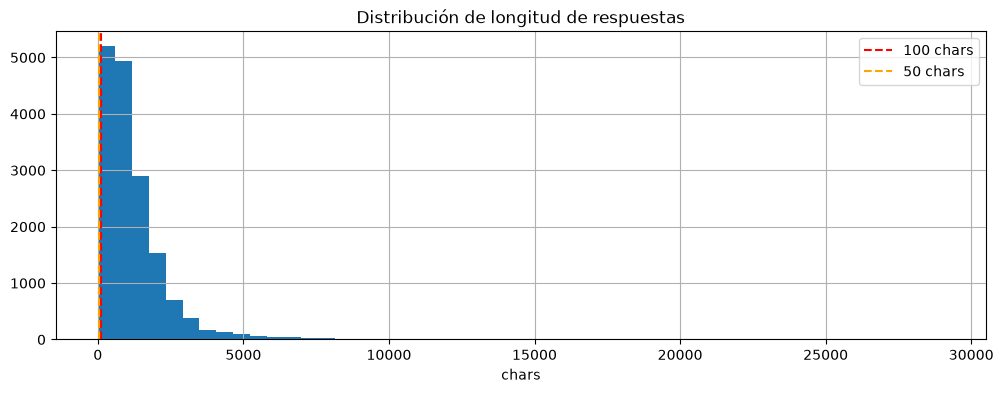

                                                                                                                                                       answer  answer_len
921                              This condition is rare; the exact incidence is unknown. More than 175 cases have been reported in the scientific literature.         124
11567                                      NINDS supports research on Cushing's syndrome aimed at finding new ways to diagnose, treat, and cure the disorder.         114
4431        Adolescent idiopathic scoliosis is the most common spinal abnormality in children. It affects an estimated 2 to 3 percent of children in the U.S.         145
1981                                                                                 The prevalence of myoclonic epilepsy myopathy sensory ataxia is unknown.          72
4316                                                                          Juvenile primary lateral sclerosis is a rare disorder, with few reported

In [ ]:
import matplotlib.pyplot as plt

df['answer_len'] = df['answer'].str.strip().str.len()

print(df['answer_len'].describe())

df['answer_len'].hist(bins=50, figsize=(12,4))
plt.axvline(100, color='red', linestyle='--', label='100 chars')
plt.axvline(50, color='orange', linestyle='--', label='50 chars')
plt.legend()
plt.title('Distribución de longitud de respuestas')
plt.xlabel('chars')
plt.show()

# Ver ejemplos en el borde del umbral
print(df[df['answer_len'].between(50, 150)][['answer', 'answer_len']].sample(20).to_string())

In [ ]:
garbage_answers = ['frequently asked questions (faqs)', 'topics']
mask_garbage = df['answer'].str.lower().str.strip().isin(garbage_answers)

print(f"A eliminar: {mask_garbage.sum():,}")
display(df[mask_garbage][['question', 'answer', 'document_source']])

before = len(df)
df = df[~mask_garbage].copy()
print(f"Eliminadas: {before - len(df):,} | Restantes: {len(df):,}")

A eliminar: 1


,question,answer,document_source
33094,How to prevent Acanthamoeba - Granulomatous Am...,Topics,CDC


Eliminadas: 1 | Restantes: 16,401


In [ ]:
MIN_ANSWER_LEN = 50  # chars mínimos para considerar una respuesta válida

before = len(df)
short_mask = df['answer'].str.strip().str.len() < MIN_ANSWER_LEN
print(f"Cantidad de respuestas con menos de {MIN_ANSWER_LEN} chars: {short_mask.sum():,}")
print(df[short_mask][['question', 'answer', 'document_source']].to_string())

Cantidad de respuestas con menos de 50 chars: 29
                                                                                           question                                             answer document_source
3301                                How many people are affected by spinocerebellar ataxia type 1 ?  SCA1 affects 1 to 2 per 100,000 people worldwide.             GHR
3416                 How many people are affected by esophageal atresia/tracheoesophageal fistula ?     EA/TEF occurs in 1 in 3,000 to 5,000 newborns.             GHR
3431                              How many people are affected by tyrosine hydroxylase deficiency ?        The prevalence of TH deficiency is unknown.             GHR
3476                                              How many people are affected by erythromelalgia ?      The prevalence of erythromelalgia is unknown.             GHR
3506   How many people are affected by blepharophimosis, ptosis, and epicanthus inversus syndrome ?                 

Nos damos cuenta que varias respuestas tienen como contenido a la pregunta, y esto puede
generar ruido en el modelo de RAG, ya que al recuperar estos chunks el LLM recibirá como
contexto información que no responde nada, llevando a respuestas vacías o incorrectas.

### Paso 3 — Eiminar preguntas en la columna de respuestas

In [ ]:
def contar_respuestas_que_empiezan_con_pregunta(df, col='answer', mostrar_ejemplos=10):
    patron = re.compile(
        r'^\s*(what|how|why|when|where|which|who|whom|whose|is|are|am|was|were|do|does|did|can|could|would|should|will|has|have|had)\b[^?]{0,300}\?',
        flags=re.IGNORECASE
    )

    serie = df[col].fillna('').astype(str)
    mask = serie.apply(lambda x: bool(patron.search(x)))

    total = int(mask.sum())
    print(f"Respuestas que empiezan con pregunta en '{col}': {total}")

    if mostrar_ejemplos > 0 and total > 0:
        print(f"\nEjemplos ({min(mostrar_ejemplos, total)}):")
        for texto in serie[mask].head(mostrar_ejemplos):
            print(f"- {texto[:250]}...\n")

    return mask

In [ ]:
mask_preguntas = contar_respuestas_que_empiezan_con_pregunta(df, col='answer', mostrar_ejemplos=10)

Respuestas que empiezan con pregunta en 'answer': 4017

Ejemplos (10):
- What are the signs and symptoms of hypothalamic dysfunction? The signs and symptoms of hypothalamic dysfunction may vary from person to person depending on the specific hormones missing. You can read more by visiting the following link from MedlinePl...

- What causes hypothalamic dysfunction? Hypothalamic dysfunction may be caused by any of the following : Birth defects of the brain or hypothalamus (e.g. holoprosencephaly, septo-optic dysplasia) Genetic disorders (e.g. Prader-Willi syndrome, growth ho...

- How might hypothalamic dysfunction be treated? Treatment is based on the specific cause of the hypothalamic dysfunction. For instance, if the condition is caused by a tumor, radiation and/or surgery may be warranted. If the hypothalamic dysfunction i...

- What are the signs and symptoms of Mental retardation X-linked syndromic 11? The Human Phenotype Ontology provides the following list of signs and symptoms 

In [ ]:
df[mask_preguntas][['question', 'answer']].head(20)

,question,answer
5431,What are the symptoms of Hypothalamic dysfunct...,What are the signs and symptoms of hypothalami...
5432,What causes Hypothalamic dysfunction ?,What causes hypothalamic dysfunction? Hypothal...
5433,What are the treatments for Hypothalamic dysfu...,How might hypothalamic dysfunction be treated?...
5434,What are the symptoms of Mental retardation X-...,What are the signs and symptoms of Mental reta...
5435,What are the symptoms of Diffuse cutaneous mas...,What are the signs and symptoms of Diffuse cut...
5437,What are the symptoms of Cushing disease ?,What are the signs and symptoms of Cushing dis...
5439,What are the symptoms of Focal dermal hypoplas...,What are the signs and symptoms of Focal derma...
5440,Is Focal dermal hypoplasia inherited ?,How is this condition inherited? Focal dermal ...
5442,What are the symptoms of Dihydropteridine redu...,What are the signs and symptoms of Dihydropter...
5444,What are the symptoms of Plasminogen activator...,What are the signs and symptoms of Plasminogen...


In [ ]:
def limpiar_answers_con_preguntas_iniciales(df, col_answer='answer', mostrar_ejemplos=10):
    df = df.copy()

    def normalizar_texto(txt):
        txt = '' if txt is None else str(txt)
        txt = txt.strip()
        txt = re.sub(r'\s+', ' ', txt)      # colapsa espacios múltiples
        txt = re.sub(r'\s+\?', '?', txt)    # quita espacios antes de ?
        return txt

    # pregunta inicial válida: solo si aparece al comienzo real del texto
    # o tras signos muy leves de arranque como guiones, viñetas o espacios
    patron_pregunta_inicial = re.compile(
        r'^(?:[-•*:\s"]+)?[^?]{1,500}\?\s*',
        flags=re.IGNORECASE
    )

    def limpiar_inicio_preguntas(txt):
        txt = normalizar_texto(txt)

        while True:
            m = patron_pregunta_inicial.match(txt)
            if not m:
                break

            bloque = m.group(0).strip()

            # Validar que realmente parece pregunta inicial y no texto informativo cualquiera.
            # Exigimos que el bloque empiece con una palabra típica de pregunta en inglés.
            if not re.match(
                r'^(?:[-•*:\s"]+)?'
                r'(what|how|why|when|where|which|who|whom|whose|is|are|am|was|were|do|does|did|can|could|would|should|will|has|have|had)\b',
                bloque,
                flags=re.IGNORECASE
            ):
                break

            txt = txt[m.end():].strip()

        return txt

    a = df[col_answer].fillna('').astype(str)
    a_norm = a.apply(normalizar_texto)
    a_limpio = a_norm.apply(limpiar_inicio_preguntas)

    mask_modificados = a_norm != a_limpio
    print(f"Registros modificados: {int(mask_modificados.sum())}")

    if mostrar_ejemplos > 0 and mask_modificados.sum() > 0:
        print(f"\nEjemplos ({min(mostrar_ejemplos, int(mask_modificados.sum()))}):")
        indices = df.index[mask_modificados][:mostrar_ejemplos]

        for i in indices:
            print(f"- ANTES  : {a_norm.loc[i][:180]}")
            print(f"  DESPUÉS: {a_limpio.loc[i][:180]}\n")

    df[col_answer] = a_limpio

    mask_vacios = df[col_answer].fillna('').astype(str).str.strip().eq('')
    print(f"Registros eliminados por quedar vacíos: {int(mask_vacios.sum())}")

    df = df.loc[~mask_vacios].copy()

    return df

In [ ]:
df = limpiar_answers_con_preguntas_iniciales(df, col_answer='answer')

Registros modificados: 4017

Ejemplos (10):
- ANTES  : What are the signs and symptoms of hypothalamic dysfunction? The signs and symptoms of hypothalamic dysfunction may vary from person to person depending on the specific hormones mi
  DESPUÉS: The signs and symptoms of hypothalamic dysfunction may vary from person to person depending on the specific hormones missing. You can read more by visiting the following link from 

- ANTES  : What causes hypothalamic dysfunction? Hypothalamic dysfunction may be caused by any of the following : Birth defects of the brain or hypothalamus (e.g. holoprosencephaly, septo-opt
  DESPUÉS: Hypothalamic dysfunction may be caused by any of the following : Birth defects of the brain or hypothalamus (e.g. holoprosencephaly, septo-optic dysplasia) Genetic disorders (e.g. 

- ANTES  : How might hypothalamic dysfunction be treated? Treatment is based on the specific cause of the hypothalamic dysfunction. For instance, if the condition is caused by a tumor, r

In [ ]:
before = len(df)
mask = df['answer'].str.startswith('More detailed information', na=False)
print(f"Filas a eliminar: {mask.sum():,}")
print(df[mask][['question', 'answer', 'document_source']].to_string())

df = df[~mask].copy()
print(f"Eliminadas: {before - len(df):,} | Restantes: {len(df):,}")

Filas a eliminar: 6
                                                  question                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

### Paso 4 — Eliminar pares `question + answer` duplicados
> **Motivo:** 585 pares idénticos introducen bias en evaluación. Conservamos la primera ocurrencia.

In [ ]:
before = len(df)
df = df.drop_duplicates(subset=['question', 'answer'], keep='first').copy()
print(f"Eliminadas {before - len(df):,} filas duplicadas (question+answer)")
print(f"Filas restantes: {len(df):,}")

Eliminadas 51 filas duplicadas (question+answer)
Filas restantes: 16,326


### Paso 5 — Eliminar preguntas duplicadas (texto)
> **Motivo:** 2,838 preguntas con el mismo texto pero distintas respuestas o fuentes. Conservamos la versión con respuesta más larga (más informativa).

In [ ]:
before = len(df)

# Ordenar por longitud de respuesta descendente antes de deduplicar
df = df.sort_values('answer', key=lambda s: s.str.len(), ascending=False)

# Tabla de preguntas duplicadas con conteo
duplicated_mask = df.duplicated(subset=['question'], keep=False)
print(f"Filas duplicadas totales: {duplicated_mask.sum():,}")

conteo = df[duplicated_mask].groupby('question').size().reset_index(name='repeticiones').sort_values('repeticiones', ascending=False)
display(conteo)

# Muestra de las primeras 50 filas duplicadas
print("\nMuestra de las primeras 50 filas duplicadas:")
display(df[duplicated_mask][['question', 'answer', 'document_source']].sort_values('question').head(50))

Filas duplicadas totales: 2,236


,question,repeticiones
487,What is (are) High Blood Cholesterol ?,19
543,What is (are) Medicare and Continuing Care ?,14
642,What is (are) Skin Cancer ?,13
650,What is (are) Stroke ?,13
170,What are the treatments for Breast Cancer ?,12
...,...,...
13,How to diagnose High Blood Cholesterol ?,2
12,How to diagnose Hemochromatosis ?,2
9,How to diagnose Diagnosis of Diabetes and Pred...,2
8,How to diagnose Diabetic Kidney Disease ?,2



Muestra de las primeras 50 filas duplicadas:


,question,answer,document_source
33484,How to diagnose Adrenal Insufficiency and Addi...,"After Addisons disease is diagnosed, health ca...",NIDDK
33483,How to diagnose Adrenal Insufficiency and Addi...,"In its early stages, adrenal insufficiency can...",NIDDK
15086,How to diagnose Alzheimer's Caregiving ?,Now that your family member or friend has rece...,NIHSeniorHealth
15092,How to diagnose Alzheimer's Caregiving ?,When you learn that someone has Alzheimers dis...,NIHSeniorHealth
15165,How to diagnose Alzheimer's Disease ?,The only definitive way to diagnose Alzheimer'...,NIHSeniorHealth
15166,How to diagnose Alzheimer's Disease ?,"An early, accurate diagnosis of Alzheimer's di...",NIHSeniorHealth
15167,How to diagnose Alzheimer's Disease ?,The time from diagnosis of Alzheimers disease ...,NIHSeniorHealth
33965,How to diagnose Amyloidosis and Kidney Disease ?,A health care provider diagnoses primary amylo...,NIDDK
33966,How to diagnose Amyloidosis and Kidney Disease ?,A health care provider diagnoses dialysis-rela...,NIDDK
15581,How to diagnose Breast Cancer ?,"Most cancers in their early, most treatable st...",NIHSeniorHealth


In [ ]:
df = df.drop_duplicates(subset=['question'], keep='first').copy()
df = df.sort_index()

print(f"\nEliminadas {before - len(df):,} preguntas duplicadas (texto)")
print(f"Filas restantes: {len(df):,}")
print(f"Preguntas duplicadas (texto): {df['question'].duplicated().sum():,}")


Eliminadas 1,369 preguntas duplicadas (texto)
Filas restantes: 14,957
Preguntas duplicadas (texto): 0


### Paso 6 — Reasignar `question_id` único
> **Motivo:** El campo `question_id` original se reutiliza entre fuentes distintas (ej. `0000001-1` aparece en GHR, NINDS, ADAM, etc.). Para RAG necesitamos IDs globalmente únicos.

In [ ]:
# Guardar el original por trazabilidad
df['question_id_original'] = df['question_id']

# Nuevo ID: source + id_original + índice para garantizar unicidad
df = df.reset_index(drop=True)
df['question_id'] = (
    df['document_source'].str.upper().str.replace(' ', '_') + '_' +
    df['question_id_original'].str.replace('/', '-') + '_' +
    df.index.astype(str)
)

print(f"IDs duplicados después de reasignación: {df['question_id'].duplicated().sum()}")
print("Ejemplo IDs nuevos:")
print(df['question_id'].head(5).values)

IDs duplicados después de reasignación: 0
Ejemplo IDs nuevos:
<ArrowStringArray>
['GHR_0000559-1_0', 'GHR_0000559-2_1', 'GHR_0000559-3_2', 'GHR_0000559-4_3',
 'GHR_0000559-5_4']
Length: 5, dtype: str


### Paso 7 — Normalizar texto de `answer` y `question`
El ruido de whitespace afecta negativamente a los embeddings.

In [ ]:
def normalize_text(text: str) -> str:
    if not isinstance(text, str):
        return text
    # Reemplazar tabs por espacio
    text = text.replace('\t', ' ')
    # Colapsar múltiples espacios en uno
    text = re.sub(r' {2,}', ' ', text)
    # Limpiar espacios antes de saltos de línea
    text = re.sub(r' +\n', '\n', text)
    # Colapsar más de 2 saltos de línea consecutivos
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text.strip()

df['answer']   = df['answer'].apply(normalize_text)
df['question'] = df['question'].apply(normalize_text)

# Verificación
tabs_after = df['answer'].str.contains(r'\t').sum()
double_space_after = df['answer'].str.contains(r'  ').sum()
print(f"Tabs en answer después de limpieza   : {tabs_after}")
print(f"Doble espacio en answer tras limpieza: {double_space_after}")

Tabs en answer después de limpieza   : 0
Doble espacio en answer tras limpieza: 0


### Paso 8 — Marcar respuestas genéricas repetidas
> **Motivo:** La respuesta de herencia autosómica recesiva se repite 348 veces. Es válida como contenido médico, pero al usarla como ground truth en evaluación puede sesgar las métricas. La marcamos para poder filtrarla opcionalmente en los sets de evaluación.

In [ ]:
# =========================
# 1. Normalizar respuestas
# =========================
df['answer_norm'] = (
    df['answer']
    .fillna('')
    .astype(str)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
    .str.lower()
)

# ==========================================================
# 2. Marcar como genéricas las respuestas que se repiten mucho
# ==========================================================
GENERIC_THRESHOLD = 5
answer_counts = df['answer_norm'].value_counts()
generic_answers = set(answer_counts[answer_counts > GENERIC_THRESHOLD].index)

df['answer_is_generic'] = df['answer_norm'].isin(generic_answers)

print(f"Respuestas distintas marcadas como genéricas (>{GENERIC_THRESHOLD} apariciones): {len(generic_answers)}")
print(f"Filas afectadas antes del recorte: {df['answer_is_generic'].sum():,}")
print("\nTop respuestas genéricas (primeros 120 caracteres):")
for ans in list(generic_answers)[:10]:
    print(f"  [{answer_counts[ans]}x] {ans[:120]}...")

# ============================================
# 3. Recortar respuestas genéricas repetidas
# ============================================
df_generic = df[df['answer_is_generic']].copy()
df_non_generic = df[~df['answer_is_generic']].copy()

df_generic_limited = (
    df_generic
    .groupby('answer_norm', group_keys=False)
    .head(GENERIC_THRESHOLD)
    .copy()
)

df = pd.concat([df_non_generic, df_generic_limited], ignore_index=True)
df = df.sort_index()

print("\nTop respuestas repetidas después del recorte:")
top_counts = df['answer_norm'].value_counts().head(10)
for ans, count in top_counts.items():
    print(f"  [{count}x] {ans[:120]}...")

df.drop(columns=['answer_norm'], inplace=True)

# ============================================
# 4. Resumen después del recorte
# ============================================
print(f"\n{'='*50}")
print(f"Filas genéricas antes del recorte : {len(df_generic):,}")
print(f"Filas genéricas después del recorte: {len(df_generic_limited):,}")
print(f"Eliminadas por recorte             : {len(df_generic) - len(df_generic_limited):,}")
print(f"{'='*50}")
print(f"Filas totales finales              : {len(df):,}")

Respuestas distintas marcadas como genéricas (>5 apariciones): 7
Filas afectadas antes del recorte: 464

Top respuestas genéricas (primeros 120 caracteres):
  [63x] this condition is inherited in an autosomal dominant pattern, which means one copy of the altered gene in each cell is s...
  [12x] this condition is inherited in an x-linked recessive pattern. the gene associated with this condition is located on the ...
  [342x] this condition is inherited in an autosomal recessive pattern, which means both copies of the gene in each cell have mut...
  [7x] osteopetrosis is a bone disease that makes bones abnormally dense and prone to breakage (fracture). researchers have des...
  [25x] new types of treatment are being tested in clinical trials. information about clinical trials is available from the nci ...
  [8x] this condition is inherited in an autosomal dominant pattern, which means one copy of the altered gene in each cell is s...
  [7x] this condition is inherited in an autosomal d

Durante el análisis se detectó que ciertas respuestas médicas válidas aparecen
cientos de veces en el dataset. Por ejemplo, la respuesta sobre herencia
autosómica recesiva se repetía 348 veces con texto idéntico.

Esto es problemático para RAG por dos razones:

1. **Sesgo en evaluación**: si una respuesta domina el dataset, el modelo puede
   obtener buenas métricas simplemente por frecuencia, no por calidad de recuperación.

2. **Redundancia en el índice vectorial**: tener 348 chunks idénticos no aporta
   diversidad semántica y ocupa espacio innecesario.

La solución no fue eliminarlas completamente, ya que son respuestas médicamente
válidas, sino **limitar cada respuesta única a un máximo de 5 apariciones**.
Esto preserva el patrón para que el modelo lo aprenda, sin que distorsione
las métricas de evaluación.

### Paso 9 — Marcar respuestas muy largas
> **Motivo:** El modelo `all-mpnet-base-v2` tiene un límite de 384 tokens
(~1,500 chars aproximados en inglés). Textos que superen este umbral serán
truncados silenciosamente, perdiendo información clave.

El análisis muestra que aproximadamente el 25% del dataset supera los 1,500 chars,
con un máximo de 26,976 chars. Estas respuestas serán marcadas con
`answer_needs_chunking = True`.

In [ ]:
MAX_ANSWER_LEN = 1500

df['answer_len'] = df['answer'].str.len()
df['answer_needs_chunking'] = df['answer_len'] > MAX_ANSWER_LEN

print(f"Respuestas que necesitan chunking (>{MAX_ANSWER_LEN} chars): {df['answer_needs_chunking'].sum():,}")
print(f"\nDistribución de longitud de respuestas:")
print(df['answer_len'].describe().round(0))

print(f"\nDistribución por rangos:")
bins = [0, 500, 1000, 2000, 5000, 10000, float('inf')]
labels = ['0-500', '500-1k', '1k-2k', '2k-5k', '5k-10k', '>10k']
print(df['answer_len'].pipe(pd.cut, bins=bins, labels=labels).value_counts().sort_index())

Respuestas que necesitan chunking (>1500 chars): 4,083

Distribución de longitud de respuestas:
count    14528.0
mean      1307.0
std       1575.0
min         34.0
25%        506.0
50%        918.0
75%       1589.0
max      26976.0
Name: answer_len, dtype: float64

Distribución por rangos:
answer_len
0-500     3580
500-1k    4216
1k-2k     4475
2k-5k     1932
5k-10k     226
>10k        99
Name: count, dtype: int64


### Paso 10 — Rellenar `question_focus` nulo
> **Motivo:** 14 filas sin `question_focus`. Se puede inferir del `document_url` o dejar como 'unknown'.

In [ ]:
def infer_focus_from_url(row):
    """Intenta extraer el tema del último segmento de la URL."""
    if pd.notna(row['question_focus']):
        return row['question_focus']
    try:
        slug = row['document_url'].rstrip('/').split('/')[-1]
        # quitar extensiones y reemplazar guiones
        slug = re.sub(r'\.(html|htm|aspx)$', '', slug)
        return slug.replace('-', ' ').replace('_', ' ').strip() or 'unknown'
    except Exception:
        return 'unknown'

null_focus_before = df['question_focus'].isnull().sum()
df['question_focus'] = df.apply(infer_focus_from_url, axis=1)
null_focus_after = df['question_focus'].isnull().sum()

print(f"question_focus nulos antes : {null_focus_before}")
print(f"question_focus nulos después: {null_focus_after}")

question_focus nulos antes : 13
question_focus nulos después: 0


In [ ]:
df.describe(include="all")

,document_id,document_source,document_url,category,question_id,question_focus,question_type,question,answer,answer_len,question_id_original,answer_is_generic,answer_needs_chunking
count,14528,14528,14528,867,14528,14528,14528,14528,14528,14528.000000,14528,14528,14528
unique,3474,9,5342,2,14528,5127,16,14528,14432,NaN,10897,2,2
top,0000001,GARD,https://www.cancer.gov/types/myeloproliferativ...,Disease,GHR_0000559-1_0,Prostate Cancer,information,What is (are) keratoderma with woolly hair ?,This condition is inherited in an X-linked dom...,NaN,0000004-1,False,False
freq,34,5174,20,572,1,11,3815,1,5,NaN,7,14493,10445
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1306.954777,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1574.552750,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,506.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,917.500000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1589.000000,NaN,NaN,NaN


### Paso 11 — Construir splits train / val / test
> Para RAG se recomienda separar los splits **antes** de indexar. Las preguntas de val/test no deben estar en el índice de documentos.

> **Nota de este proyecto:** estos splits se hicieron a nivel de *pregunta* y para evaluar retrieval. El generador de examenes necesita splits a nivel de *chunk* y agrupados por documento, que se construyen en el notebook 02. Se dejan corriendo por fidelidad al notebook original, pero la salida que consume el notebook 02 es `medqa_clean.parquet`, no `medqa_train.parquet`.


In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Excluir respuestas genéricas del set de evaluación
df_eval_pool = df[~df['answer_is_generic']].copy()
df_generic   = df[df['answer_is_generic']].copy()

use_stratify = df_eval_pool['question_type'].value_counts().min() >= 2

train_val, test = train_test_split(
    df_eval_pool,
    test_size=0.1,
    random_state=42,
    stratify=df_eval_pool['question_type'] if use_stratify else None
)

use_stratify_2 = train_val['question_type'].value_counts().min() >= 2

train, val = train_test_split(
    train_val,
    test_size=0.111,
    random_state=42,
    stratify=train_val['question_type'] if use_stratify_2 else None
)

train = pd.concat([train, df_generic], ignore_index=True)

print(f"Train : {len(train):,} ({len(train)/len(df)*100:.1f}%)")
print(f"Val   : {len(val):,} ({len(val)/len(df)*100:.1f}%)")
print(f"Test  : {len(test):,} ({len(test)/len(df)*100:.1f}%)")

Train : 11,630 (80.1%)
Val   : 1,448 (10.0%)
Test  : 1,450 (10.0%)


### Resumen final y guardado

In [ ]:
print("=" * 50)
print("RESUMEN DEL PROCESO DE LIMPIEZA")
print("=" * 50)
print(f"Filas originales              : {len(df_raw):>8,}")
print(f"  - Sin answer (eliminadas)   : {len(df_raw[df_raw['answer'].isna()]):>8,}")
print(f"  - Pares duplicados (elim.)  : {585:>8,}")
print(f"  - Preguntas duplicadas      : {2838:>8,}")
print(f"Filas limpias totales         : {len(df):>8,}")
print(f"  - Marcadas como genéricas   : {df['answer_is_generic'].sum():>8,}")
print(f"  - Necesitan chunking        : {df['answer_needs_chunking'].sum():>8,}")
print()
print("Columnas nuevas añadidas:")
new_cols = ['question_id_original', 'answer_is_generic', 'answer_needs_chunking', 'answer_len']
for c in new_cols:
    print(f"  + {c}")

print("\nDistribución final por fuente:")
print(df['document_source'].value_counts())

RESUMEN DEL PROCESO DE LIMPIEZA
Filas originales              :   47,441
  - Sin answer (eliminadas)   :   31,034
  - Pares duplicados (elim.)  :      585
  - Preguntas duplicadas      :    2,838
Filas limpias totales         :   14,528
  - Marcadas como genéricas   :       35
  - Necesitan chunking        :    4,083

Columnas nuevas añadidas:
  + question_id_original
  + answer_is_generic
  + answer_needs_chunking
  + answer_len

Distribución final por fuente:
document_source
GARD                 5174
GHR                  4937
NINDS                1045
MPlusHealthTopics     867
NIDDK                 815
CancerGov             647
NHLBI                 532
NIHSeniorHealth       262
CDC                   249
Name: count, dtype: int64


In [ ]:
from pathlib import Path
# Guardar archivos limpios
Path("../data").mkdir(exist_ok=True)
df.to_parquet("../data/medqa_clean.parquet", index=False)
train.to_parquet("../data/medqa_train.parquet", index=False)
val.to_parquet("../data/medqa_val.parquet",   index=False)
test.to_parquet("../data/medqa_test.parquet", index=False)

print("Archivos guardados:")
print("  medqa_clean.parquet  — dataset limpio completo")
print("  medqa_train.parquet  — split de entrenamiento/indexación")
print("  medqa_val.parquet    — split de validación")
print("  medqa_test.parquet   — split de test (evaluación final RAG)")

Archivos guardados:
  medqa_clean.parquet  — dataset limpio completo
  medqa_train.parquet  — split de entrenamiento/indexación
  medqa_val.parquet    — split de validación
  medqa_test.parquet   — split de test (evaluación final RAG)


# Parte 2 — Dataset sintético de preguntas

*Notebook original: `02_dataset_mcq.ipynb`.*


# 02 - Dataset de preguntas de opcion multiple

Convierte el corpus limpio en las dos tablas que consume el resto del proyecto.

| Salida | Para que sirve |
|---|---|
| `data/chunks.parquet` | **la base de datos de la aplicacion**: todos los fragmentos aptos, sin preguntas |
| `data/muestra_api.parquet` | el subconjunto que pasa por la API para construir el set de entrenamiento |

La decision de alcance mas importante del proyecto esta en la seccion 2.3: **no**
se generan preguntas para todos los fragmentos. Solo una muestra pasa por la API,
y existe unicamente para entrenar. Los demas los cubre el modelo afinado cuando un
usuario los pida. Eso es lo que justifica el fine-tuning.

Secciones 2.1 a 2.3. La generacion con el LLM (2.4) viene despues.

## 0. Preparacion

In [ ]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
from langchain_text_splitters import RecursiveCharacterTextSplitter

DATA = Path("../data")
SEMILLA = 42
pd.set_option("display.max_colwidth", 90)

clean = pd.read_parquet(DATA / "medqa_clean.parquet")
print(f"corpus limpio: {len(clean):,} filas, {clean['document_id'].nunique():,} documentos")
clean.head(2)

corpus limpio: 14,528 filas, 3,474 documentos


,document_id,document_source,document_url,category,question_id,question_focus,question_type,question,answer,answer_len,question_id_original,answer_is_generic,answer_needs_chunking
0,0000559,GHR,https://ghr.nlm.nih.gov/condition/keratoderma-with-woolly-hair,NaN,GHR_0000559-1_0,keratoderma with woolly hair,information,What is (are) keratoderma with woolly hair ?,Keratoderma with woolly hair is a group of related conditions that affect the skin and...,1921,0000559-1,False,True
1,0000559,GHR,https://ghr.nlm.nih.gov/condition/keratoderma-with-woolly-hair,NaN,GHR_0000559-2_1,keratoderma with woolly hair,frequency,How many people are affected by keratoderma with woolly hair ?,Keratoderma with woolly hair is rare; its prevalence worldwide is unknown. Type I (Nax...,469,0000559-2,False,False


### Nota sobre `category`

El notebook 01 conserva la columna `category` pensando en usarla como dimension
de seleccion en la aplicacion. Conviene mirar si de verdad sirve antes de
apoyarse en ella.

In [ ]:
print(clean["category"].value_counts(dropna=False).to_string())
pct_nulo = clean["category"].isna().mean() * 100
print(f"\nnulos: {pct_nulo:.0f}%")
print(f"question_type : {clean['question_type'].nunique()} valores")
print(f"question_focus: {clean['question_focus'].nunique():,} valores")

category
NaN        13661
Disease      572
Other        295

nulos: 94%
question_type : 16 valores
question_focus: 5,127 valores


**Conclusion:** `category` queda casi vacia despues de la limpieza, y la
categoria `Drug` -que era un tercio del dataset crudo- desaparece por completo.
No sirve como dimension de seleccion.

**El selector de la aplicacion se construye con `question_type` (16 valores, el
tipo de pregunta) y `question_focus` (miles de valores, la enfermedad concreta).**
La columna se conserva porque no molesta, pero no se depende de ella.

## 2.1 Fragmentacion

Se reutiliza la estrategia **B_512** del proyecto anterior: `chunk_size=512` con
`chunk_overlap=64`. La razon vale tambien para esta tarea aunque sea otra:
alrededor de 512 caracteres es un hecho medico completo, que es la unidad correcta
para formular **una** pregunta. Con fragmentos mas grandes el modelo tiene que
elegir arbitrariamente sobre que preguntar, y las preguntas salen vagas.

### Por que se mantiene el solape de 64

En el proyecto de RAG el solape servia para que un hecho partido por la frontera
apareciera entero en algun fragmento, y asi fuera recuperable. Aqui esa razon no
aplica, pero hay otra: **compensa el recorte de la seccion 2.2**.

Sin solape, la oracion que el troceado parte se pierde del todo: no esta al final
del fragmento anterior (recortado) ni al principio del siguiente (recortado
tambien). Medido sobre 1,200 respuestas:

| Estrategia | Aptos | Texto conservado | Casi-duplicados |
|---|---|---|---|
| **solape 64** | 2,926 | **72.7%** | 7 |
| sin solape | 2,675 | 67.0% | 5 |
| sin solape, cortando en oraciones | 3,015 | 66.0% | 5 |

El riesgo esperable del solape -preguntas casi identicas generadas desde dos
fragmentos que comparten texto- **no se materializa**: 7 pares en casi 3,000
fragmentos, igual que sin solape. La razon es que el recorte elimina justamente
la zona solapada, que es el final de una oracion partida. El solape evita que el
texto se pierda y el recorte evita que se duplique.

Cortar directamente en fronteras de oracion (tercera fila) baja los fragmentos
cortados del 90% al 74%, pero conserva menos texto porque desperdicia el espacio
sobrante de cada fragmento. El recorte ya resuelve los cortes sin ese costo.

### Clave primaria

Un cambio respecto del codigo original: alli `chunk_id` era el indice dentro del
documento (0, 1, 2...), que no es unico globalmente. Aqui hace falta una clave
primaria de verdad, porque cada pregunta generada tiene que poder rastrearse hasta
su fragmento y hasta la pagina del NIH de la que salio.

In [ ]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=512, chunk_overlap=64, length_function=len,
)

registros = []
for fila in clean.itertuples(index=False):
    partes = splitter.split_text(fila.answer)
    for i, texto in enumerate(partes):
        registros.append({
            "chunk_uid"        : f"{fila.question_id}__{i}",
            "chunk_text"       : texto,
            "chunk_idx"        : i,
            "n_chunks"         : len(partes),
            "question_id"      : fila.question_id,
            "document_id"      : fila.document_id,
            "question"         : fila.question,
            "question_focus"   : fila.question_focus,
            "question_type"    : fila.question_type,
            "category"         : fila.category,
            "document_source"  : fila.document_source,
            "document_url"     : fila.document_url,
            "answer_is_generic": fila.answer_is_generic,
        })

chunks = pd.DataFrame(registros)
chunks["n_chars"] = chunks["chunk_text"].str.len()

print(f"fragmentos          : {len(chunks):,}")
print(f"clave unica         : {chunks['chunk_uid'].is_unique}")
print(f"caracteres de media : {chunks['n_chars'].mean():.0f}")
print(f"fragmentos por respuesta: {chunks.groupby('question_id').size().mean():.1f} de media")

fragmentos          : 47,771
clave unica         : True
caracteres de media : 439
fragmentos por respuesta: 3.3 de media


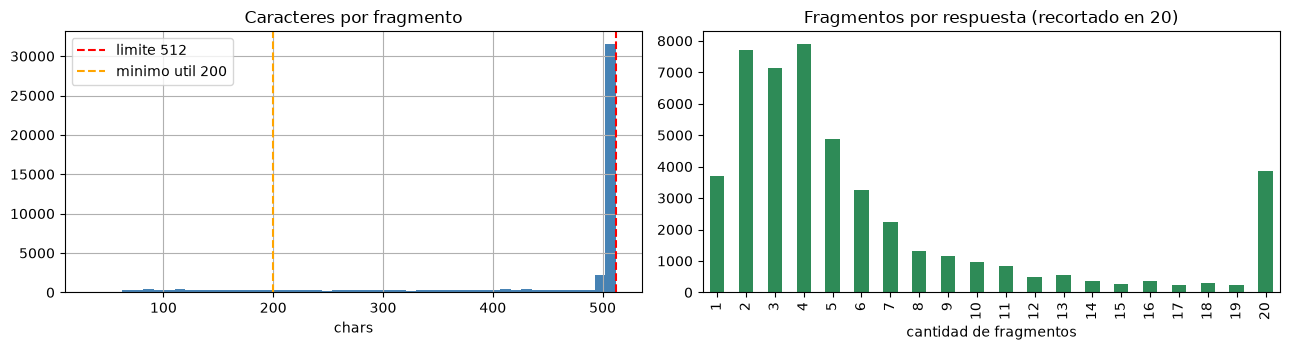

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
chunks["n_chars"].hist(bins=50, ax=ax[0], color="steelblue")
ax[0].axvline(512, color="red", linestyle="--", label="limite 512")
ax[0].axvline(200, color="orange", linestyle="--", label="minimo util 200")
ax[0].set_title("Caracteres por fragmento")
ax[0].set_xlabel("chars")
ax[0].legend()

chunks["n_chunks"].clip(upper=20).value_counts().sort_index().plot(
    kind="bar", ax=ax[1], color="seagreen")
ax[1].set_title("Fragmentos por respuesta (recortado en 20)")
ax[1].set_xlabel("cantidad de fragmentos")
plt.tight_layout()
plt.show()

## 2.2 Filtro de aptitud

No todo fragmento sirve para formular una pregunta de examen. Este filtro es
barato y corre **antes** de gastar llamadas a la API.

| Criterio | Se descarta si |
|---|---|
| Muy corto | menos de 200 caracteres: no alcanza para una pregunta con respaldo |
| Sin oracion completa | arrancaba cortado y no quedo nada tras recortar el arranque |
| Casi todo enumeracion | mas del 60% de las lineas son items de lista, **o** la lista viene aplanada en un solo renglon con guiones y porcentajes |
| Sin oracion afirmativa | no contiene ningun verbo que sostenga una afirmacion |
| Boilerplate del HPO | es el texto fijo del Human Phenotype Ontology mas una tabla de porcentajes, sin afirmacion medica |
| Generico | `answer_is_generic`: respuestas de relleno repetidas en el corpus |

El de "arranca cortado" es el que mas importa: con solape de 64 caracteres, la
mayoria de los fragmentos intermedios empieza a mitad de oracion, y una pregunta
construida sobre uno de ellos sale sin sujeto o directamente mal.

Pero descartarlos sin mas seria un desperdicio: son mas de la mitad del corpus y
su contenido es legitimo, solo les sobra el arranque. **Antes de descartar se
intenta recuperarlos** recortando hasta la primera oracion completa. Solo si lo
que queda sigue siendo demasiado corto se descarta el fragmento.

El mismo problema aparece **al final**: el 78% de los fragmentos termina a mitad
de frase. Un final colgando -"...downturned corners of the mouth, and a"- es peor
que un arranque cortado, porque invita al modelo a completar de su propio
conocimiento lo que el fragmento no llego a decir. Tambien se recorta.

### Lo que este filtro no puede ver

Los criterios son **sintacticos**: descartan lo obviamente inservible, no
seleccionan lo bueno. No miran si el fragmento contiene un hecho concreto sobre
el que se pueda preguntar.

Revisando dos muestras de 12 fragmentos a mano, el residuo que queda es de un
solo tipo: **texto institucional generico**, sobre todo sobre ensayos clinicos
("Patients who take part in a clinical trial may receive the standard treatment
or be among the first to receive a new treatment"). Es prosa correcta, con verbos
y sin listas, asi que ningun criterio sintactico lo distingue de contenido
medico real. Pero no afirma nada sobre ninguna enfermedad.

Filtrarlo por palabras clave descartaria tambien fragmentos buenos que solo
*mencionan* un ensayo clinico. Asi que se deja para la seccion 2.4, donde el
modelo puede responder `{"descartar": true}` ante un fragmento del que no se
puede extraer una pregunta con respuesta concreta. **Ese es el proposito de esa
salida**, y conviene medir cuantas veces se usa: es la tasa real de fragmentos
no aptos que el filtro sintactico deja pasar.

In [ ]:
MIN_CHARS = 200
MAX_RATIO_LISTA = 0.60

# Verbos que sostienen una afirmacion en el ingles del corpus. No se busca un
# analisis gramatical: alcanza con distinguir una oracion de una lista de
# sintagmas nominales.
VERBOS = re.compile(
    r"\b(?:is|are|was|were|be|been|has|have|had|can|may|might|will|would|should|"
    r"causes?|caused|includes?|occurs?|affects?|results?|leads?|means?|refers?|"
    r"happens?|develops?|produces?|involves?|requires?|helps?|prevents?|treats?)\b",
    re.IGNORECASE,
)
# El Human Phenotype Ontology aporta un bloque de texto fijo que explica que es
# la HPO y luego vuelca una tabla de sintomas con porcentajes. Es identificable
# por su literal y no contiene una afirmacion medica sobre la que preguntar.
BOILERPLATE_HPO = re.compile(
    r"Human Phenotype Ontology|Signs and Symptoms Approximate number of patients|"
    r"MedlinePlus Medical Dictionary to look up|comes from Orphanet|"
    # la cola del mismo bloque, que cae en el fragmento siguiente y ya no
    # menciona la HPO: explica como leer las frecuencias, no la enfermedad
    r"frequencies are based on a specific study|"
    r"no information on frequency is available|"
    r"frequency of \d+/\d+ means|"
    r"frequency may also be listed as a fraction",
    re.IGNORECASE,
)
INICIO_LISTA = re.compile(r"^\s*(?:[-*\u2022\u00b7]|\(?\d+[.)]|[a-z][.)])\s+")


SEPARADOR_ITEM = re.compile(r"\s-\s")
PORCENTAJE = re.compile(r"\d+(?:[.,]\d+)?%")


def es_lista_aplanada(texto):
    """Detecta listas que el corpus trae en una sola linea.

    `ratio_lineas_lista` cuenta lineas que empiezan con vinieta, pero muchas
    tablas del corpus vienen aplanadas en un solo renglon con guiones o
    porcentajes intercalados: "Arrhythmia 7.5% Absent eyebrow - Bradycardia -
    Fair hair - ...". No hay prosa sobre la que preguntar.
    """
    items = len(SEPARADOR_ITEM.findall(texto)) + len(PORCENTAJE.findall(texto))
    palabras = max(len(texto.split()), 1)
    return items >= 5 and items / palabras > 0.06


def ratio_lineas_lista(texto):
    lineas = [l for l in texto.splitlines() if l.strip()]
    if not lineas:
        return 1.0
    return sum(bool(INICIO_LISTA.match(l)) for l in lineas) / len(lineas)


def arranca_cortado(texto):
    """Un fragmento que no empieza una oracion nueva.

    Dos casos: empieza en minuscula (continua la oracion anterior), o empieza
    con puntuacion, que pasa cuando el corte parte una palabra con guion
    ("-tendinous") o cae dentro de un parentesis.
    """
    t = texto.lstrip()
    return (not t) or t[0].islower() or t[0] in "-–—,;:)"


FIN_ORACION = re.compile(r"(?<=[.!?])\s+(?=[A-Z0-9])")


def recortar_al_inicio_de_oracion(texto):
    """Devuelve el texto desde la primera oracion completa.

    Los fragmentos intermedios arrancan a mitad de frase por el solape. En vez
    de tirarlos, se les quita el arranque incompleto: lo que queda es texto
    valido y suele ser la mayor parte del fragmento.
    """
    t = texto.lstrip()
    if not arranca_cortado(t):      # misma condicion que decide el rescate
        return t
    corte = FIN_ORACION.search(t)
    return t[corte.end():] if corte else ""


CIERRES = (".", "!", "?")


def termina_en_oracion(texto):
    """True si el fragmento cierra una oracion, admitiendo comillas o parentesis."""
    t = texto.rstrip().rstrip("'" + chr(34) + ")]")
    return bool(t) and t[-1] in CIERRES


def recortar_al_final_de_oracion(texto):
    """Devuelve el texto hasta la ultima oracion completa.

    El troceado por caracteres corta a mitad de frase: 78% de los fragmentos
    terminaba asi. Un final colgando ("...downturned corners of the mouth, and
    a") invita al modelo a completar de su propio conocimiento lo que el
    fragmento no dice, que es justo lo que hay que evitar.
    """
    t = texto.rstrip()
    if not t or termina_en_oracion(t):
        return t
    # ultimo signo de puntuacion que cierra oracion, sin depender de escapes
    posiciones = [t.rfind(c) for c in (".", "!", "?")]
    ultimo = max(posiciones)
    return t[:ultimo + 1] if ultimo > 0 else ""


rescatables = chunks["chunk_text"].map(arranca_cortado)
chunks["chunk_text"] = np.where(
    rescatables,
    chunks["chunk_text"].map(recortar_al_inicio_de_oracion),
    chunks["chunk_text"].str.lstrip(),
)
# y ahora el final, que el troceado tambien deja colgando
cortados_al_final = ~chunks["chunk_text"].map(termina_en_oracion)
chunks["chunk_text"] = chunks["chunk_text"].map(recortar_al_final_de_oracion)
chunks["n_chars"] = chunks["chunk_text"].str.len()
chunks["fue_recortado"] = (rescatables | cortados_al_final) & chunks["n_chars"].gt(0)

perdidos = int((rescatables & chunks["chunk_text"].str.len().eq(0)).sum())
print(f"fragmentos que arrancaban cortados : {int(rescatables.sum()):,}")
print(f"  recuperados recortando           : {int(chunks['fue_recortado'].sum()):,}")
print(f"  sin ninguna oracion completa     : {perdidos:,}")
print()
print(f"fragmentos que terminaban cortados : {int(cortados_al_final.sum()):,}")
print(f"caracteres de media tras recortar  : {chunks['n_chars'].mean():.0f} "
      f"(antes del recorte de final: 380)")



motivos = pd.DataFrame({
    "muy_corto"      : chunks["n_chars"] < MIN_CHARS,
    "sin_oracion_completa": chunks["n_chars"] == 0,
    "casi_todo_lista": (chunks["chunk_text"].map(ratio_lineas_lista) > MAX_RATIO_LISTA)
                       | chunks["chunk_text"].map(es_lista_aplanada),
    "sin_verbo"      : ~chunks["chunk_text"].str.contains(VERBOS, regex=True),
    "boilerplate_hpo": chunks["chunk_text"].str.contains(BOILERPLATE_HPO, regex=True),
    "generico"       : chunks["answer_is_generic"].astype(bool),
})

resumen = pd.DataFrame({
    "descartados por este criterio": motivos.sum(),
    "% del total": (motivos.mean() * 100).round(1),
}).sort_values("descartados por este criterio", ascending=False)
print(resumen.to_string())

descartar = motivos.any(axis=1)
print(f"\nfragmentos totales : {len(chunks):,}")
print(f"descartados        : {descartar.sum():,} ({descartar.mean() * 100:.1f}%)")
print(f"APTOS              : {(~descartar).sum():,}")

fragmentos que arrancaban cortados : 28,124
  recuperados recortando           : 38,293
  sin ninguna oracion completa     : 3,393

fragmentos que terminaban cortados : 35,130
caracteres de media tras recortar  : 308 (antes del recorte de final: 380)


                      descartados por este criterio  % del total
muy_corto                                     11359         23.8
boilerplate_hpo                                7888         16.5
casi_todo_lista                                6440         13.5
sin_verbo                                      6413         13.4
sin_oracion_completa                           4887         10.2
generico                                         55          0.1

fragmentos totales : 47,771
descartados        : 19,477 (40.8%)
APTOS              : 28,294


In [ ]:
# Muestra de descartes, para comprobar que el filtro no se lleva material bueno
for criterio in motivos.columns:
    solo_este = motivos[criterio] & ~motivos.drop(columns=[criterio]).any(axis=1)
    sel = chunks.loc[solo_este]
    print(f"\n=== {criterio} - descartados solo por este motivo: {len(sel):,} ===")
    for texto in sel["chunk_text"].head(2):
        print("   ", " ".join(texto.split())[:150], "...")


=== muy_corto - descartados solo por este motivo: 4,882 ===
    Type IV does not appear to cause cardiomyopathy. ...
    In other conditions, encephaloceles may be associated with intellectual disability; however, most people with Knobloch syndrome have normal intelligen ...

=== sin_oracion_completa - descartados solo por este motivo: 0 ===

=== casi_todo_lista - descartados solo por este motivo: 647 ===
    Genetic Testing Registry: Parkinson disease 7 - Genetic Testing Registry: Parkinson disease 8, autosomal dominant - Genetic Testing Registry: Parkinso ...
    These resources address the diagnosis or management of proopiomelanocortin deficiency: - Eunice Kennedy Shriver National Institute of Child Health and ...

=== sin_verbo - descartados solo por este motivo: 214 ===
    The signals triggered by the FGFR2, FGFR3, and FGF10 genes appear to stimulate cells to form the structures that make up the lacrimal glands, salivary ...
    (after age 25) than those with larger GAA trinucle

In [ ]:
aptos = chunks.loc[~descartar].copy().reset_index(drop=True)
aptos.to_parquet(DATA / "chunks.parquet", index=False)

print(f"guardado data/chunks.parquet - {len(aptos):,} fragmentos")
print(f"respuestas representadas: {aptos['question_id'].nunique():,}")
print(f"temas (question_focus)  : {aptos['question_focus'].nunique():,}")
print()
print(aptos["question_type"].value_counts().to_string())

guardado data/chunks.parquet - 28,294 fragmentos
respuestas representadas: 10,196
temas (question_focus)  : 3,794

question_type
information        9380
treatment          5226
genetic changes    3074
exams and tests    2360
symptoms           1488
causes             1467
inheritance        1443
stages              708
susceptibility      702
prevention          699
research            656
frequency           405
outlook             293
considerations      291
complications       101
support groups        1


## 2.3 Muestreo para la API

> **La tabla completa de fragmentos es la base de datos de la aplicacion. El
> subconjunto que pasa por la API existe unicamente para entrenar al modelo.**

De ahi que no haga falta generar preguntas para todos los fragmentos. Unos pocos
miles alcanzan de sobra para LoRA, y el resto queda cubierto por el modelo afinado
cuando un usuario pida ese tema. Precisamente eso es lo que justifica haber
entrenado: si se generaran todas por API, bastaria una tabla y el modelo sobraria.

El muestreo es **estratificado por `question_type`** para que el modelo vea todos
los tipos de pregunta, con dos cuidados:

- un **tope** por estrato, para que `information` -el mas numeroso- no domine;
- un **minimo** por estrato, para que los tipos raros no desaparezcan.

`support groups` tiene un solo fragmento en todo el corpus, asi que ningun
esquema proporcional lo conservaria. El minimo lo resuelve.

In [ ]:
OBJETIVO = 6000        # fragmentos que pasan por la API
MIN_POR_TIPO = 60      # piso para que los tipos raros sobrevivan
TOPE_POR_TIPO = 1200   # techo para que `information` no domine

conteo = aptos["question_type"].value_counts()
cuota = {}
for tipo, disponibles in conteo.items():
    proporcional = int(round(OBJETIVO * disponibles / len(aptos)))
    objetivo_tipo = max(min(MIN_POR_TIPO, disponibles), min(proporcional, TOPE_POR_TIPO))
    cuota[tipo] = int(min(disponibles, objetivo_tipo))

reparto = pd.DataFrame({
    "disponibles" : conteo,
    "proporcional": (conteo / len(aptos) * OBJETIVO).round(0).astype(int),
    "cuota final" : pd.Series(cuota),
})
reparto["% del corpus"]    = (reparto["disponibles"] / len(aptos) * 100).round(1)
reparto["% de la muestra"] = (reparto["cuota final"] / reparto["cuota final"].sum() * 100).round(1)
print(reparto.to_string())
print(f"\ntotal a generar: {reparto['cuota final'].sum():,}")

                 disponibles  proporcional  cuota final  % del corpus  % de la muestra
information             9380          1989         1200          33.2             22.9
treatment               5226          1108         1108          18.5             21.1
genetic changes         3074           652          652          10.9             12.4
exams and tests         2360           500          500           8.3              9.5
symptoms                1488           316          316           5.3              6.0
causes                  1467           311          311           5.2              5.9
inheritance             1443           306          306           5.1              5.8
stages                   708           150          150           2.5              2.9
susceptibility           702           149          149           2.5              2.8
prevention               699           148          148           2.5              2.8
research                 656           139 

### Diversidad de temas dentro de cada estrato

Un riesgo del muestreo aleatorio simple: que caigan varios fragmentos de la misma
respuesta y el modelo vea el mismo tema repetido. Se evita tomando **un fragmento
por respuesta** mientras se pueda, y completando con un segundo solo si la cuota
no se llena.

In [ ]:
seleccion = []

for tipo, n in cuota.items():
    pool = aptos[aptos["question_type"] == tipo]
    # primera pasada: como maximo un fragmento por respuesta
    primera = (pool.sample(frac=1, random_state=SEMILLA)
                   .drop_duplicates(subset="question_id", keep="first"))
    tomados = primera.head(n)
    if len(tomados) < n:                       # completar con los que quedaron
        resto = pool.drop(index=tomados.index)
        faltan = min(n - len(tomados), len(resto))
        if faltan > 0:
            tomados = pd.concat([tomados, resto.sample(n=faltan, random_state=SEMILLA)])
    seleccion.append(tomados)

muestra = (pd.concat(seleccion)
             .sample(frac=1, random_state=SEMILLA)
             .reset_index(drop=True))
muestra.to_parquet(DATA / "muestra_api.parquet", index=False)

pct_div = muestra["question_id"].nunique() / len(muestra) * 100
print(f"muestra para la API : {len(muestra):,} fragmentos")
print(f"respuestas distintas: {muestra['question_id'].nunique():,} ({pct_div:.0f}% - cuanto mas alto, mas diverso)")
print(f"temas distintos     : {muestra['question_focus'].nunique():,}")
print(f"caracteres de media : {muestra['n_chars'].mean():.0f}")
print()
print(muestra["question_type"].value_counts().to_string())

muestra para la API : 5,250 fragmentos
respuestas distintas: 5,148 (98% - cuanto mas alto, mas diverso)
temas distintos     : 2,471
caracteres de media : 389

question_type
information        1200
treatment          1108
genetic changes     652
exams and tests     500
symptoms            316
causes              311
inheritance         306
stages              150
susceptibility      149
prevention          148
research            139
frequency            86
outlook              62
considerations       62
complications        60
support groups        1


In [ ]:
# Costo estimado de la seccion 2.4, antes de gastar nada
TOK_ENTRADA = muestra["n_chars"].mean() / 4 + 220   # fragmento + instruccion
TOK_SALIDA = 160
PRECIO_IN, PRECIO_OUT = 0.15 / 1e6, 0.60 / 1e6      # gpt-4o-mini, USD por token

costo = len(muestra) * (TOK_ENTRADA * PRECIO_IN + TOK_SALIDA * PRECIO_OUT)
print(f"tokens de entrada por llamada (estimado): {TOK_ENTRADA:.0f}")
print(f"llamadas                                : {len(muestra):,}")
print(f"COSTO ESTIMADO                          : USD {costo:.2f}")

tokens de entrada por llamada (estimado): 317
llamadas                                : 5,250
COSTO ESTIMADO                          : USD 0.75


## Estado

| Archivo | Contenido |
|---|---|
| `data/chunks.parquet` | fragmentos aptos - **la base de datos de la aplicacion** |
| `data/muestra_api.parquet` | los que pasan por la API en la seccion 2.4 |

Siguiente paso: la generacion con el LLM. Conviene correrla primero sobre unos
200 fragmentos y revisar las preguntas a mano antes de escalar a la muestra
completa, porque el prompt define la calidad de todo el set de entrenamiento.

## 2.4 Generacion con el LLM

Un llamado por fragmento. El punto que resuelve el problema de las respuestas
larguisimas: **la respuesta correcta no es el fragmento, sino una afirmacion
corta extraida de el**, con tope de 15 palabras.

### Piloto antes de escalar

Esta seccion corre primero sobre **200 fragmentos**, no sobre los 5,250. El
prompt define la calidad de todo el set de entrenamiento, y ajustarlo despues de
gastar la muestra completa seria tirar el trabajo. El piloto cuesta unos 3
centavos y responde tres preguntas que el filtro sintactico dejo abiertas:

| Que se mide | Por que importa |
|---|---|
| **tasa de `descartar`** | es la medicion real de cuantos fragmentos no aptos dejo pasar el filtro de §2.2. Si supera el 5%, el filtro se queda corto |
| tasa de JSON valido | si el modelo maestro ya falla el formato, el prompt esta mal |
| tasa de rechazo por cada filtro de calidad | si un filtro descarta el 40%, el problema es el prompt, no el filtro |

Ademas hay que **leer preguntas a mano**. Ninguna metrica automatica detecta una
pregunta que tiene dos respuestas correctas o que esta mal planteada.

In [ ]:
import json, os, random, time
from concurrent.futures import ThreadPoolExecutor, as_completed

from openai import OpenAI

MODELO_API = "gpt-4o-mini"
N_PILOTO = 200
HILOS = 12
TEMPERATURA = 0.7

from dotenv import load_dotenv
load_dotenv("../.env")                 # la clave vive fuera del notebook
client = OpenAI() if HAY_API else None                      # lee OPENAI_API_KEY del entorno
SALIDA = DATA / "mcq_piloto_v2.jsonl"

### El prompt

Cinco reglas, cada una atada a un fallo concreto que se observo:

1. **Respuesta corta y longitudes parejas.** Sin esto las cuatro opciones serian
   parrafos de 400 caracteres. Y si la correcta es siempre la mas larga, se
   acierta sin saber el tema.
2. **Distractores inequivocamente falsos.** En la prueba de humo el modelo puso
   "ansiedad y estres" como distractor de una pregunta sobre cefalea tensional,
   cuando el fragmento dice que estan relacionadas. Un distractor cierto arruina
   la pregunta.
3. **Pregunta autocontenida.** "Segun el fragmento, que..." no se sostiene en un
   examen, donde el estudiante no ve el fragmento.
4. **Espanol neutro latinoamericano.** Sin fijarlo, el modelo mezcla registros.
5. **`descartar: true`.** La valvula de escape para los fragmentos que el filtro
   sintactico no supo rechazar. Es preferible perder un fragmento a envenenar el
   set de entrenamiento con una pregunta mala, porque el modelo aprenderia a
   imitarla.

In [ ]:
PROMPT = """Eres un docente de medicina que redacta preguntas de examen.

PASO 1 - Decide si el FRAGMENTO sirve.
Un fragmento sirve solo si afirma algo concreto sobre una enfermedad, un
sintoma, un tratamiento o un mecanismo biologico. NO sirve si habla de sitios
web, registros, bases de datos, folletos, a quien esta dirigido un recurso,
ensayos clinicos en general, o si solo recomienda consultar a un profesional.
Ante la duda, descartalo: es preferible perder un fragmento a escribir una
pregunta que no es de medicina.

PASO 2 - Si sirve, escribe UNA pregunta de opcion multiple.

Reglas obligatorias:
- La respuesta correcta debe estar explicitamente respaldada por el fragmento.
- Las tres opciones incorrectas deben ser plausibles para alguien que no estudio
  el tema, pero INEQUIVOCAMENTE FALSAS segun el fragmento. Si el fragmento dice
  que algo es cierto, no puede aparecer como opcion incorrecta.
- Las cuatro opciones deben ser MUTUAMENTE EXCLUYENTES y claramente distintas.
  Nunca escribas dos opciones que signifiquen lo mismo con otras palabras
  ("profesionales de la salud" y "proveedores de salud" son la misma opcion).
- Las CUATRO opciones: maximo 15 palabras cada una y de longitud similar.
- Debe haber UNA SOLA respuesta correcta.
- La pregunta debe entenderse sola, sin ver el fragmento. Prohibido escribir
  "segun el fragmento", "el texto menciona" o "de acuerdo al documento".
- Prefiere preguntas de dificultad MEDIA: que exijan relacionar dos datos del
  fragmento o distinguir entre conceptos parecidos, en vez de repetir un dato
  literal. Una pregunta cuya respuesta se copia tal cual de una sola frase es
  demasiado facil.
- Traduce los terminos medicos al espanol. Si el termino tecnico en ingles es
  el de uso habitual, ponlo entre parentesis despues del espanol.
- Escribe en espanol neutro latinoamericano. Si usas verbos en imperativo o
  segunda persona, usa tuteo y no voseo: "elige" y no "elegi".
- No inventes datos que no esten en el fragmento.

Responde SIEMPRE con un JSON que empiece por el campo "apto".

Si el fragmento NO sirve:
{"apto": false, "motivo": "por que no sirve, en pocas palabras"}

Si SI sirve:
{"apto": true, "pregunta": "...", "correcta": "...",
 "incorrectas": ["...", "...", "..."], "dificultad": "facil|media|dificil"}"""

print(PROMPT[:400], "...")

Eres un docente de medicina que redacta preguntas de examen.

PASO 1 - Decide si el FRAGMENTO sirve.
Un fragmento sirve solo si afirma algo concreto sobre una enfermedad, un
sintoma, un tratamiento o un mecanismo biologico. NO sirve si habla de sitios
web, registros, bases de datos, folletos, a quien esta dirigido un recurso,
ensayos clinicos en general, o si solo recomienda consultar a un profesi ...


### Generacion

Concurrencia con hilos, reintentos con espera creciente, y guardado incremental
a JSONL para poder reanudar si se corta. Cada linea del JSONL conserva el
`chunk_uid` y la respuesta cruda del modelo: si mas adelante hay que rehacer el
parseo o los filtros, no hace falta volver a pagar.

In [ ]:
def pedir_una(fila, reintentos=3):
    """Genera la pregunta de un fragmento. Devuelve el registro crudo."""
    mensajes = [
        {"role": "system", "content": PROMPT},
        {"role": "user", "content": "FRAGMENTO:\n" + fila["chunk_text"]},
    ]
    for intento in range(reintentos):
        try:
            t0 = time.time()
            r = client.chat.completions.create(
                model=MODELO_API, messages=mensajes,
                temperature=TEMPERATURA, max_tokens=320,
            )
            return {
                "chunk_uid": fila["chunk_uid"],
                "crudo": r.choices[0].message.content,
                "tok_in": r.usage.prompt_tokens,
                "tok_out": r.usage.completion_tokens,
                "segundos": round(time.time() - t0, 2),
                "error": None,
            }
        except Exception as exc:
            if intento == reintentos - 1:
                return {"chunk_uid": fila["chunk_uid"], "crudo": None,
                        "tok_in": 0, "tok_out": 0, "segundos": 0,
                        "error": f"{type(exc).__name__}: {exc}"}
            time.sleep(2 ** intento)


def generar(df, salida):
    """Genera para todo el DataFrame, saltando lo ya hecho en `salida`."""
    hechos = set()
    if salida.exists():
        with open(salida, encoding="utf-8") as fh:
            # un registro con error NO cuenta como hecho: se reintenta
            hechos = {r["chunk_uid"] for r in map(json.loads, filter(str.strip, fh))
                      if not r.get("error")}
        print(f"reanudando: {len(hechos):,} ya generados")

    pendientes = df[~df["chunk_uid"].isin(hechos)].to_dict("records")
    if not pendientes:
        print("nada pendiente")
        return

    t0 = time.time()
    with open(salida, "a", encoding="utf-8") as fh, ThreadPoolExecutor(HILOS) as pool:
        futuros = {pool.submit(pedir_una, f): f for f in pendientes}
        for i, fut in enumerate(as_completed(futuros), 1):
            fh.write(json.dumps(fut.result(), ensure_ascii=False) + "\n")
            fh.flush()
            if i % 50 == 0 or i == len(pendientes):
                print(f"  {i:,}/{len(pendientes):,}  ({time.time()-t0:.0f}s)", flush=True)


# Reparto proporcional por tipo, sin `apply`: en pandas 3 la columna de
# agrupacion no llega al DataFrame que recibe la funcion.
partes = []
for tipo, grupo in muestra.groupby("question_type"):
    n = max(1, round(N_PILOTO * len(grupo) / len(muestra)))
    partes.append(grupo.head(n))
piloto = pd.concat(partes).reset_index(drop=True)
print(f"piloto: {len(piloto)} fragmentos sobre {piloto['question_type'].nunique()} tipos")
if HAY_API:
    generar(piloto, SALIDA)
else:
    # Sin API: el piloto se toma de la generacion completa guardada, que uso el
    # mismo prompt sobre los mismos fragmentos. No se gasta nada.
    ids_piloto = set(piloto["chunk_uid"])
    with open(DATA / "mcq_crudo.jsonl", encoding="utf-8") as fe:
        guardadas = [l for l in fe if l.strip() and json.loads(l)["chunk_uid"] in ids_piloto]
    with open(SALIDA, "w", encoding="utf-8") as fs:
        fs.writelines(guardadas)
    print(f"piloto tomado de la cache: {len(guardadas)} respuestas, sin llamar a la API")


piloto: 201 fragmentos sobre 16 tipos
reanudando: 201 ya generados
nada pendiente


### Lo que revela el piloto

In [ ]:
crudos = [json.loads(l) for l in open(SALIDA, encoding="utf-8")]
print(f"registros: {len(crudos)}")

fallidos = [c for c in crudos if c["error"]]
print(f"errores de API: {len(fallidos)}")

def parsear(texto):
    if not texto:
        return None
    t = texto.strip()
    if t.startswith("```"):
        t = t.strip("`").removeprefix("json").strip()
    try:
        return json.loads(t)
    except Exception:
        return None

parseados = [(c, parsear(c["crudo"])) for c in crudos if not c["error"]]
json_ok = [(c, d) for c, d in parseados if d is not None]
descartados = [(c, d) for c, d in json_ok if d.get("apto") is False or d.get("descartar")]
generadas = [(c, d) for c, d in json_ok if d.get("pregunta")]

n = len(parseados)
print()
print(f"JSON valido al primer intento : {len(json_ok)}/{n}  ({len(json_ok)/n*100:.1f}%)")
print(f"el modelo DESCARTO el fragmento: {len(descartados)}/{n}  ({len(descartados)/n*100:.1f}%)")
print(f"preguntas generadas            : {len(generadas)}")
print()
coste = sum(c["tok_in"] for c in crudos) * 0.15/1e6 + sum(c["tok_out"] for c in crudos) * 0.60/1e6
print(f"tokens: {sum(c['tok_in'] for c in crudos):,} entrada / {sum(c['tok_out'] for c in crudos):,} salida")
print(f"costo del piloto: USD {coste:.3f}  ->  extrapolado a {len(muestra):,}: USD {coste/len(crudos)*len(muestra):.2f}")

registros: 201
errores de API: 0

JSON valido al primer intento : 201/201  (100.0%)
el modelo DESCARTO el fragmento: 12/201  (6.0%)
preguntas generadas            : 189

tokens: 134,818 entrada / 16,875 salida
costo del piloto: USD 0.030  ->  extrapolado a 5,250: USD 0.79


**La cifra que hay que mirar es la tasa de `descartar`.** Es la medicion
directa de cuantos fragmentos no aptos dejo pasar el filtro sintactico de §2.2.
Por encima del 5% conviene volver sobre el filtro antes de escalar.

In [ ]:
from collections import Counter
motivos = Counter(d.get("motivo", "(sin motivo)")[:70] for _, d in descartados)
print("por que descarto el modelo:")
for m, k in motivos.most_common(10):
    print(f"  {k:>3}  {m}")

print()
tipos = pd.Series([c["chunk_uid"] for c, _ in descartados])
mapa = muestra.set_index("chunk_uid")["question_type"]
print("descartes por tipo de pregunta:")
print(tipos.map(mapa).value_counts().to_string())

por que descarto el modelo:
    1  porque el fragmento no afirma nada concreto sobre una enfermedad, sínt
    1  el fragmento habla de recursos y recomendaciones sobre pruebas genétic
    1  El fragmento habla sobre programas de seguro de salud y no sobre enfer
    1  El fragmento habla sobre investigaciones y no proporciona información 
    1  El fragmento no afirma nada concreto sobre una enfermedad, síntoma, tr
    1  El fragmento no habla de una enfermedad, síntoma o tratamiento específ
    1  El fragmento habla sobre ensayos clínicos en general y no sobre una en
    1  El fragmento no se centra en una enfermedad, síntoma, tratamiento o me
    1  habla de un sitio web y no proporciona información sobre la enfermedad
    1  no contiene información concreta sobre una enfermedad, síntoma, tratam

descartes por tipo de pregunta:
treatment          4
research           3
exams and tests    2
information        1
prevention         1
susceptibility     1


### Revision a mano

Ninguna metrica automatica detecta una pregunta con dos respuestas correctas o
mal planteada. Hay que leerlas.

In [ ]:
muestra_texto = muestra.set_index("chunk_uid")["chunk_text"]
random.seed(7)
for c, d in random.sample(generadas, min(10, len(generadas))):
    print("=" * 96)
    print("FRAGMENTO:", " ".join(muestra_texto[c["chunk_uid"]].split())[:230], "...")
    print()
    print("  P:", d["pregunta"], f"   [{d.get('dificultad')}]")
    print("  ->", d["correcta"], "   (correcta)")
    for inc in d["incorrectas"]:
        print("  - ", inc)
    print()

FRAGMENTO: Pustular psoriasis is a rare form of psoriasis that is characterized by widespread pustules and reddish skin. This condition can occur alone or with plaque-type psoriasis. Most cases of pustular psoriasis are thought to be "multif ...

  P: ¿Cuál de los siguientes factores puede desencadenar la psoriasis pustulosa?    [media]
  -> Retiro de corticosteroides    (correcta)
  -  Uso excesivo de corticosteroides
  -  Infecciones virales únicamente
  -  Cambio de dieta repentino

FRAGMENTO: Similar changes in the structure of the DMPK and CNBP genes cause the two forms of myotonic dystrophy. In each case, a segment of DNA is abnormally repeated many times, forming an unstable region in the gene. The mutated gene prod ...

  P: ¿Qué producen las mutaciones en los genes DMPK y CNBP en la distrofia miotónica?    [media]
  -> Una versión expandida del ARN mensajero    (correcta)
  -  Proteínas defectuosas que no funcionan
  -  Una reducción en la producción de proteínas
  -  Un aumen

### Que mostro el piloto, y que se corrigio

Se corrieron **dos versiones del prompt** sobre los mismos 201 fragmentos:

| | v1 | v2 |
|---|---|---|
| JSON valido al primer intento | 100% | 100% |
| **Descarta el fragmento** | **0 (0%)** | **12 (6.0%)** |
| Dificultad: facil / media | 197 / 4 | 2 / 187 |
| Dos opciones muy parecidas | 11.9% | 9.0% |
| Opciones sobre 15 palabras | 0 | 0 |

Con la v1 el modelo **nunca** uso la salida de descarte: ante un fragmento sobre
el publico objetivo de un sitio web genero igual una pregunta, que no es de
medicina. La v2 lo arregla obligandolo a decidir primero, con un campo `apto`
que va antes que nada, y describiendo con ejemplos que **no** es contenido medico.

Ese 6% es el dato que faltaba: **es la proporcion de fragmentos no aptos que el
filtro sintactico de §2.2 deja pasar**. Revisando los 12 descartes a mano, 8 son
correctos (sitios web, seguros medicos, ensayos clinicos, listas de enlaces) y 3
son falsos positivos: fragmentos con contenido medico legitimo que el modelo
descarto dando ademas un motivo que no se corresponde con el texto. Perder un
1.5% de material bueno para atrapar un 4% de malo es un intercambio favorable
cuando hay 28,294 fragmentos disponibles y solo se necesitan 5,250.

La v2 tambien corrige el sesgo de dificultad: la v1 producia preguntas de dato
literal casi siempre. Ninguna de las dos genera preguntas "dificiles"; se acepta
como limitacion.

Defectos residuales, todos filtrables en §2.5: un **9%** con dos opciones
demasiado parecidas y un **2.1%** que se refiere al fragmento ("la prueba de
heces mencionada"), que el estudiante no ve.

## 2.4.b Generacion sobre la muestra completa

Con el prompt validado se corre sobre los 5,250 fragmentos. Mismo codigo y misma
funcion `generar`: el JSONL se escribe incrementalmente y la corrida se reanuda
sola si se interrumpe.

In [ ]:
SALIDA_COMPLETA = DATA / "mcq_crudo.jsonl"

# La cache trae las 5,250 respuestas originales: si la muestra coincide, no se
# llama a la API y el dataset es el mismo con el que se entreno.
en_cache = set()
if SALIDA_COMPLETA.exists():
    for l in open(SALIDA_COMPLETA, encoding="utf-8"):
        if l.strip() and not json.loads(l).get("error"):
            en_cache.add(json.loads(l)["chunk_uid"])
faltan = len(set(muestra["chunk_uid"]) - en_cache)
print(f"respuestas en cache: {len(en_cache):,} | faltan por generar: {faltan:,}")
if faltan and not HAY_API:
    raise RuntimeError(f"Faltan {faltan} respuestas en la cache y la API esta desactivada. "
                       "Activa USAR_API para generarlas (cuesta dinero y cambia el dataset).")
generar(muestra, SALIDA_COMPLETA)

reanudando: 5,250 ya generados
nada pendiente


In [ ]:
crudos_full = [json.loads(l) for l in open(SALIDA_COMPLETA, encoding="utf-8")]
parseados_full = [(c, parsear(c["crudo"])) for c in crudos_full if not c["error"]]
ok_full = [(c, d) for c, d in parseados_full if d is not None]
desc_full = [(c, d) for c, d in ok_full if d.get("apto") is False]
gen_full = [(c, d) for c, d in ok_full if d.get("pregunta")]

n = len(crudos_full)
print(f"fragmentos procesados : {n:,}")
print(f"errores de API        : {sum(1 for c in crudos_full if c["error"]):,}")
print(f"JSON valido           : {len(ok_full):,} ({len(ok_full)/n*100:.1f}%)")
print(f"descartados por el LLM: {len(desc_full):,} ({len(desc_full)/n*100:.1f}%)")
print(f"PREGUNTAS GENERADAS   : {len(gen_full):,}")
print()
coste = (sum(c["tok_in"] for c in crudos_full) * 0.15 / 1e6
         + sum(c["tok_out"] for c in crudos_full) * 0.60 / 1e6)
print(f"costo real: USD {coste:.2f}")
print()
print(pd.Series([d.get("dificultad") for _, d in gen_full]).value_counts().to_string())

fragmentos procesados : 5,250
errores de API        : 0
JSON valido           : 5,247 (99.9%)
descartados por el LLM: 339 (6.5%)
PREGUNTAS GENERADAS   : 4,908

costo real: USD 0.79

media    4893
facil      15


## 2.5 Filtros de calidad

Los filtros van de mas barato a mas caro. Los primeros ocho son reglas sobre el
texto; el ultimo es un juez que lee el fragmento.

| # | Filtro | Rechaza si |
|---|---|---|
| 1 | estructura | falta un campo, o no hay exactamente 3 incorrectas |
| 2 | opciones distintas | dos opciones coinciden tras normalizar |
| 3 | opciones parecidas | dos opciones comparten mas de la mitad de sus palabras |
| 4 | longitud maxima | alguna opcion supera 15 palabras |
| 5 | longitud pareja | la opcion mas larga mide mas de 2.5 veces la mas corta |
| 6 | distractor en el fragmento | un distractor aparece textualmente en el texto fuente |
| 7 | autocontenida | la pregunta se refiere al fragmento ("la prueba mencionada") |
| 8 | pregunta negativa | pregunta por lo que NO ocurre |
| 9 | duplicada | la misma pregunta ya aparecio |

### Por que cada uno

El **5** corrige el sesgo mas comun de los examenes generados: si la correcta es
siempre la mas larga y detallada, se acierta sin saber el tema. Solo se aplica
cuando alguna opcion supera los 40 caracteres: con opciones cortas el ratio se
dispara sin que haya desequilibrio real.

El **3** descuenta el prefijo comun antes de comparar. Sin ese descuento
rechazaba preguntas bien construidas: cuatro genes distintos ("Mutaciones en el
gen CTNNB1 / APC / BRCA1 / TP53") daban 0.8 de solape por compartir el prefijo,
cuando la estructura paralela es justamente buena practica. Medido sobre las
4,908 preguntas generadas, la version anterior descartaba **220 preguntas
legitimas**.

El **6** es el mas importante para la seguridad de la pregunta. Si un distractor
esta literalmente en el fragmento, es probable que tambien sea cierto, y entonces
la pregunta tiene dos respuestas validas. El juez confirmo que ese fallo existe
en un 5.3% de los casos.

El **8** sale de la revision con el juez: las preguntas del tipo "cual factor NO
influye" exigen que tres opciones sean verdaderas y una falsa, al reves del
diseno habitual. En la muestra evaluada, las dos que aparecieron eran
defectuosas. Son el 1.7% del total, asi que descartarlas cuesta poco y elimina un
patron de riesgo completo.

In [ ]:
import re
import unicodedata

MAX_PALABRAS = 15
MAX_RATIO = 2.5
MIN_LARGO_PARA_RATIO = 40   # por debajo, las cuatro caben en un renglon
SOLAPE_MAX = 0.5

DEICTICO = re.compile(
    r"\b(mencionad[oa]s?|citad[oa]s?|el (texto|fragmento|documento|pasaje)|"
    r"seg[uu]n el|el siguiente|indicad[oa]s?)\b", re.IGNORECASE)
# "no" seguido de verbo, no el "no" de un nombre propio ("no involutivo")
NEGATIVA = re.compile(
    r"\bno\s+(influye|afecta|es|son|se|tiene|forma|corresponde|pertenece|"
    r"deber[ia]|puede|causa|produce)\b|\bexcepto\b|\bcual.{0,12}NO\b", re.IGNORECASE)


def sin_acentos(s):
    return "".join(c for c in unicodedata.normalize("NFD", str(s).lower())
                   if unicodedata.category(c) != "Mn")


def palabras(s):
    return set(re.findall(r"[a-z0-9]+", sin_acentos(s)))


def revisar(d, fragmento):
    """Devuelve la lista de filtros que la pregunta incumple."""
    fallos = []
    inc = d.get("incorrectas") or []

    if not d.get("pregunta") or not d.get("correcta") or len(inc) != 3:
        return ["1_estructura"]

    opciones = [str(d["correcta"])] + [str(x) for x in inc]
    normalizadas = [sin_acentos(o).strip(" .") for o in opciones]

    if len(set(normalizadas)) < 4:
        fallos.append("2_identicas")

    # Antes de comparar se descuenta el prefijo comun a las cuatro opciones. La
    # estructura paralela ("Mutaciones en el gen X") es BUENA practica en
    # examenes: sin este descuento, cuatro genes distintos dan 0.8 de solape
    # porque comparten "mutaciones en el gen", y se rechazaban justo las
    # preguntas mejor construidas.
    comunes = set.intersection(*(palabras(o) for o in opciones))
    distintivas = [palabras(o) - comunes for o in opciones]

    for i in range(4):
        for j in range(i + 1, 4):
            a, b = distintivas[i], distintivas[j]
            if not a or not b:
                fallos.append("3_sin_nada_propio")   # solo el prefijo comun
                break
            if len(a & b) / len(a | b) > SOLAPE_MAX:
                fallos.append("3_parecidas")
                break
        else:
            continue
        break

    if max(len(o.split()) for o in opciones) > MAX_PALABRAS:
        fallos.append("4_muy_larga")

    largos = [len(o) for o in opciones]
    # El ratio solo importa cuando alguna opcion es larga de verdad: con cuatro
    # opciones cortas ("Migrana" contra "Cefalea en racimos") 18/7 da 2.6 y las
    # dos caben en un renglon. El sesgo real es la correcta larga y detallada
    # frente a distractores de una palabra.
    if max(largos) > MIN_LARGO_PARA_RATIO and max(largos) / max(min(largos), 1) > MAX_RATIO:
        fallos.append("5_desparejas")

    frag_norm = sin_acentos(fragmento)
    for x in inc:
        t = sin_acentos(x).strip(" .")
        if len(t) > 12 and t in frag_norm:
            fallos.append("6_distractor_en_fragmento")
            break

    if DEICTICO.search(d["pregunta"]):
        fallos.append("7_no_autocontenida")

    if NEGATIVA.search(d["pregunta"]):
        fallos.append("8_negativa")

    return fallos

In [ ]:
fragmentos = muestra.set_index("chunk_uid")["chunk_text"]

filas, motivos_todos = [], []
vistas = set()
for c, d in gen_full:
    fallos = revisar(d, fragmentos[c["chunk_uid"]])
    clave = sin_acentos(d.get("pregunta", "")).strip()
    if clave in vistas:
        fallos = fallos + ["9_duplicada"]
    else:
        vistas.add(clave)
    motivos_todos.extend(fallos)
    if not fallos:
        filas.append({
            "chunk_uid"     : c["chunk_uid"],
            "pregunta"      : d["pregunta"],
            "correcta"      : d["correcta"],
            "incorrectas"   : list(d["incorrectas"]),
            "dificultad"    : d.get("dificultad", "media"),
        })

from collections import Counter
conteo = Counter(motivos_todos)
print(f"preguntas evaluadas : {len(gen_full):,}")
print()
for k, v in sorted(conteo.items()):
    print(f"  {k:<28} {v:>5,}  ({v/len(gen_full)*100:.1f}%)")
print()
print(f"  APROBADAS                    {len(filas):>5,}  ({len(filas)/len(gen_full)*100:.1f}%)")

preguntas evaluadas : 4,908

  1_estructura                     5  (0.1%)
  3_parecidas                    212  (4.3%)
  3_sin_nada_propio                5  (0.1%)
  4_muy_larga                      1  (0.0%)
  5_desparejas                    59  (1.2%)
  6_distractor_en_fragmento        7  (0.1%)
  7_no_autocontenida              63  (1.3%)
  8_negativa                      27  (0.6%)
  9_duplicada                     66  (1.3%)

  APROBADAS                    4,483  (91.3%)


In [ ]:
mcq = pd.DataFrame(filas)
meta = muestra.set_index("chunk_uid")[
    ["chunk_text", "question_id", "document_id", "question_focus",
     "question_type", "document_source", "document_url"]]
mcq = mcq.join(meta, on="chunk_uid")

print(f"dataset de preguntas: {len(mcq):,}")
print(f"  documentos distintos : {mcq['document_id'].nunique():,}")
print(f"  temas distintos      : {mcq['question_focus'].nunique():,}")
print()
print(mcq["question_type"].value_counts().to_string())
mcq.head(3)[["pregunta", "correcta", "dificultad"]]

dataset de preguntas: 4,483
  documentos distintos : 1,702
  temas distintos      : 2,330

question_type
information        1079
treatment           927
genetic changes     607
exams and tests     406
symptoms            289
causes              280
inheritance         228
susceptibility      131
stages              123
prevention          117
research             70
frequency            66
complications        57
outlook              55
considerations       47
support groups        1


,pregunta,correcta,dificultad
0,¿Cuál es la función principal del factor de crecimiento nervioso beta (NGF)?,Estimular el crecimiento y maduración de las neuronas.,media
1,¿Qué es la metástasis en el cáncer?,Es el proceso de diseminación a otras partes del cuerpo.,media
2,¿Cómo se denomina la parálisis de la mitad inferior del cuerpo?,Paraplejía,media


## 2.6 Splits sin fuga

Los fragmentos tienen 64 caracteres de solape, asi que dos fragmentos del mismo
documento comparten texto. Si uno cae en entrenamiento y el otro en prueba, la
evaluacion mide memorizacion en vez de generalizacion.

Por eso el split **agrupa por `document_id`**: todos los fragmentos de un mismo
documento van al mismo lado. Se usa `GroupShuffleSplit`, que es exactamente para
esto.

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

def partir(df, test_size, semilla=SEMILLA):
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=semilla)
    izq, der = next(gss.split(df, groups=df["document_id"]))
    return df.iloc[izq].reset_index(drop=True), df.iloc[der].reset_index(drop=True)

train_val, test = partir(mcq, test_size=0.10)
train, val = partir(train_val, test_size=0.111)

for nombre, parte in [("train", train), ("val", val), ("test", test)]:
    parte.to_parquet(DATA / f"mcq_{nombre}.parquet", index=False)
    print(f"{nombre:<6} {len(parte):>5,} preguntas | {parte['document_id'].nunique():>4,} documentos")

# verificacion: ningun documento aparece en dos splits
docs = {n: set(p["document_id"]) for n, p in
        [("train", train), ("val", val), ("test", test)]}
print()
print("fuga entre splits (documentos compartidos):")
print(f"  train-val : {len(docs['train'] & docs['val'])}")
print(f"  train-test: {len(docs['train'] & docs['test'])}")
print(f"  val-test  : {len(docs['val'] & docs['test'])}")

train  3,614 preguntas | 1,361 documentos
val      433 preguntas |  170 documentos
test     436 preguntas |  171 documentos

fuga entre splits (documentos compartidos):
  train-val : 0
  train-test: 0
  val-test  : 0


## 2.7 Nombres en espanol para la interfaz

`question_type` y `question_focus` estan en ingles porque vienen del corpus. La
aplicacion los usa como filtros internos, pero el estudiante no puede ver un
desplegable que diga "exams and tests" o "Sleep Apnea" en una app en espanol.

Se agregan dos columnas de presentacion a `chunks.parquet`:

- **`tipo_es`**: los 16 tipos, traducidos a mano. No hace falta la API.
- **`tema_es`**: los temas, traducidos en lotes con el modelo. Se hace una sola
  vez y queda guardado; la app carga una tabla lista y no traduce en tiempo real.

Ademas resuelve la busqueda: escribir "asma" tiene que encontrar los fragmentos
de `Asthma`.

In [ ]:
TIPOS_ES = {
    "information"     : "Informacion general",
    "symptoms"        : "Sintomas",
    "treatment"       : "Tratamiento",
    "genetic changes" : "Alteraciones geneticas",
    "inheritance"     : "Herencia",
    "exams and tests" : "Examenes y pruebas",
    "causes"          : "Causas",
    "frequency"       : "Frecuencia",
    "outlook"         : "Pronostico",
    "research"        : "Investigacion",
    "susceptibility"  : "Factores de riesgo",
    "prevention"      : "Prevencion",
    "considerations"  : "Consideraciones",
    "stages"          : "Estadios",
    "complications"   : "Complicaciones",
    "support groups"  : "Grupos de apoyo",
}
faltan = set(aptos["question_type"]) - set(TIPOS_ES)
print("tipos sin traducir:", faltan or "ninguno")

tipos sin traducir: ninguno


In [ ]:
TRAD_PROMPT = (
    "Traduce al espanol cada nombre de enfermedad o tema medico. Usa el nombre "
    "con el que se conoce en medicina en espanol; si es un epónimo o una sigla "
    "establecida, consérvala. Responde SOLO un JSON array de strings, en el "
    "mismo orden y con la misma cantidad de elementos que recibiste."
)

def traducir_lote(lote):
    r = client.chat.completions.create(
        model=MODELO_API, temperature=0,
        messages=[{"role": "system", "content": TRAD_PROMPT},
                  {"role": "user", "content": json.dumps(lote, ensure_ascii=False)}])
    t = r.choices[0].message.content.strip()
    if t.startswith("```"):
        t = t.strip("`").removeprefix("json").strip()
    salida = json.loads(t)
    return salida if len(salida) == len(lote) else lote   # ante duda, el original


temas = sorted(aptos["question_focus"].dropna().astype(str).unique())
print(f"temas a traducir: {len(temas):,}")

CACHE = DATA / "temas_es.json"
traducciones = json.load(open(CACHE, encoding="utf-8")) if CACHE.exists() else {}
pendientes = [t for t in temas if t not in traducciones]
print(f"pendientes: {len(pendientes):,}")

LOTE = 40
lotes = [pendientes[i:i + LOTE] for i in range(0, len(pendientes), LOTE)]
if lotes:
    with ThreadPoolExecutor(8) as pool:
        futs = {pool.submit(traducir_lote, l): l for l in lotes}
        for i, fut in enumerate(as_completed(futs), 1):
            original = futs[fut]
            try:
                for o, t in zip(original, fut.result()):
                    traducciones[o] = t
            except Exception:
                for o in original:
                    traducciones[o] = o
            if i % 20 == 0 or i == len(lotes):
                print(f"  lote {i}/{len(lotes)}", flush=True)
    json.dump(traducciones, open(CACHE, "w", encoding="utf-8"), ensure_ascii=False, indent=1)

print(f"traducidos: {len(traducciones):,}")

temas a traducir: 3,794
pendientes: 0
traducidos: 3,794


In [ ]:
aptos["tipo_es"] = aptos["question_type"].map(TIPOS_ES).fillna(aptos["question_type"])
aptos["tema_es"] = aptos["question_focus"].astype(str).map(traducciones).fillna(aptos["question_focus"])
aptos.to_parquet(DATA / "chunks.parquet", index=False)

print("chunks.parquet actualizado con tipo_es y tema_es")
print()
print(aptos[["question_focus", "tema_es"]].drop_duplicates().head(12).to_string(index=False))

chunks.parquet actualizado con tipo_es y tema_es

                                                  question_focus                                                                tema_es
                                    keratoderma with woolly hair                                       queratodermia con cabello lanoso
                                               Knobloch syndrome                                                   Síndrome de Knobloch
                                                        coloboma                                                               coloboma
                         lacrimo-auriculo-dento-digital syndrome                                síndrome lacrimo-auriculo-dento-digital
                                   spinocerebellar ataxia type 3                                         ataxia espinocerebelosa tipo 3
                                                   pilomatricoma                                                          pilomatricom

## Estado final del notebook 02

| Archivo | Contenido |
|---|---|
| `data/chunks.parquet` | fragmentos aptos, con nombres en espanol - **la BD de la app** |
| `data/mcq_train.parquet` | preguntas para entrenar |
| `data/mcq_val.parquet` | para vigilar el sobreajuste |
| `data/mcq_test.parquet` | para la comparacion base contra afinado |
| `data/mcq_crudo.jsonl` | respuestas crudas del modelo, por si hay que rehacer el parseo sin volver a pagar |

Siguiente: el notebook 03, que se corre en Colab.

# Parte 3 — Fine-tuning con LoRA

*Notebook original: `03_finetuning.ipynb`.*


# 03 - Fine-tuning con LoRA: experimentacion y modelo final

Afina `Qwen/Qwen3-4B-Instruct-2507` para que genere preguntas de opcion multiple
en espanol a partir de fragmentos medicos en ingles.

El notebook **ejecuta la experimentacion completa**, no muestra resultados
pegados:

| Seccion | Que hace | Tiempo |
|---|---|---|
| 1 | Formateo al chat template | 2 min |
| **2** | **Barrido: entrena 6 configuraciones de LoRA** | ~100 min |
| 3 | Selecciona la ganadora con criterio explicito | - |
| 4 | Entrena el modelo final con esa configuracion | ~25 min |
| 5 | Compara el modelo base con few-shot contra el afinado | ~10 min |
| 6 | Juez externo: cuanto se acerca el alumno al maestro | ~5 min |
| 7 | Guarda el adaptador y las metricas para la aplicacion | 1 min |

**Duracion total: unas 2 horas 20.** Corre igual en una GPU local o en Colab.

| Entrada | |
|---|---|
| `data/mcq_train.parquet` | 3,385 preguntas |
| `data/mcq_val.parquet` | 432, para vigilar el sobreajuste |
| `data/mcq_test.parquet` | 452, que ningun modelo ve al entrenar |

### Por que este stack y no Unsloth

`transformers` + `peft` es el stack estandar y el que se dicto en clase. El
adaptador queda compatible al moverlo entre maquinas, y con 16 GB en un modelo
de 4B no hace falta la optimizacion de memoria de Unsloth.

## 0. Entorno

In [ ]:
import gc, json, os, random, re, time, unicodedata
from pathlib import Path

# Rutas relativas a notebooks/: la preparacion del entorno ya se ubico ahi.
DATA = Path("../data")
SALIDA = Path("../app/adapter")
assert (DATA / "mcq_train.parquet").exists(), f"falta mcq_train.parquet en {DATA}: ejecuta la parte 2"
print("datos:", DATA.resolve())


entorno: local
datos: D:\ANTIGRAVITY\proyectos\proyecto_ing_iagen\data


In [ ]:
import pandas as pd
import torch

assert torch.cuda.is_available(), "hace falta GPU"
VRAM = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"GPU: {torch.cuda.get_device_name(0)}  |  {VRAM:.1f} GB  |  compute {torch.cuda.get_device_capability(0)}")

BATCH = 4 if VRAM > 30 else 2
ACUM = 8 // BATCH                    # lote efectivo de 8 en cualquier maquina
SEMILLA = 42
random.seed(SEMILLA); torch.manual_seed(SEMILLA)
print(f"lote {BATCH} x acumulacion {ACUM} = lote efectivo {BATCH * ACUM}")

# Recorta todo para validar que el notebook corre entero sin esperar 2 horas.
PRUEBA = PRUEBA_RAPIDA      # se fija en la configuracion
if PRUEBA:
    print("\nMODO PRUEBA: datos y pasos recortados")

GPU: NVIDIA GeForce RTX 5070 Ti  |  17.1 GB  |  compute (12, 0)
lote 2 x acumulacion 4 = lote efectivo 8


## 1. Formateo al chat template

Cada ejemplo se arma como un dialogo: la instruccion, el fragmento en ingles, y
el JSON esperado como respuesta.

**El detalle que mas importa:** se entrena **solo sobre la respuesta**. Los
tokens del prompt se marcan con `-100`, la etiqueta que PyTorch ignora al
calcular la perdida. Sin eso el modelo aprenderia tambien a reproducir el
fragmento en ingles, que no es la tarea y gastaria capacidad del adaptador.

In [ ]:
from transformers import AutoTokenizer

MODELO = "Qwen/Qwen3-4B-Instruct-2507"
MAX_TOKENS = 1536

INSTRUCCION = (
    "Eres un docente de medicina. A partir del FRAGMENTO escribe UNA pregunta "
    "de opcion multiple en espanol neutro. Responde SOLO con JSON."
)

tok = AutoTokenizer.from_pretrained(MODELO)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token
tok.padding_side = "left"            # obligatorio para generar por lotes


def construir(fila):
    respuesta = json.dumps({
        "apto": True, "pregunta": fila["pregunta"], "correcta": fila["correcta"],
        "incorrectas": list(fila["incorrectas"]), "dificultad": fila["dificultad"],
    }, ensure_ascii=False)
    prompt = tok.apply_chat_template(
        [{"role": "system", "content": INSTRUCCION},
         {"role": "user", "content": "FRAGMENTO:\n" + fila["chunk_text"]}],
        tokenize=False, add_generation_prompt=True)
    ip = tok(prompt, add_special_tokens=False)["input_ids"]
    ir = tok(respuesta + tok.eos_token, add_special_tokens=False)["input_ids"]
    return {"input_ids": (ip + ir)[:MAX_TOKENS],
            "labels": ([-100] * len(ip) + ir)[:MAX_TOKENS]}


def colar(lote):
    largo = max(len(x["input_ids"]) for x in lote)
    rel = lambda x, c, v: x[c] + [v] * (largo - len(x[c]))
    return {
        "input_ids": torch.tensor([rel(x, "input_ids", tok.pad_token_id) for x in lote]),
        "labels": torch.tensor([rel(x, "labels", -100) for x in lote]),
        "attention_mask": torch.tensor(
            [[1] * len(x["input_ids"]) + [0] * (largo - len(x["input_ids"])) for x in lote]),
    }


from datasets import Dataset

train_df = pd.read_parquet(DATA / "mcq_train.parquet")
val_df = pd.read_parquet(DATA / "mcq_val.parquet")
test_df = pd.read_parquet(DATA / "mcq_test.parquet")
if PRUEBA:
    train_df, val_df = train_df.head(40), val_df.head(8)

ds_train = Dataset.from_list([construir(f) for _, f in train_df.iterrows()])
ds_val = Dataset.from_list([construir(f) for _, f in val_df.iterrows()])

largos = [len(x) for x in ds_train["input_ids"]]
print(f"train {len(ds_train):,} | val {len(ds_val):,} | test {len(test_df):,}")
print(f"tokens por ejemplo: media {sum(largos)/len(largos):.0f}, max {max(largos)}")
n_resp = sum(1 for x in ds_train[0]["labels"] if x != -100)
print(f"del primer ejemplo, {n_resp} tokens de {len(ds_train[0]['labels'])} cuentan para la perdida")

train 3,614 | val 433 | test 436
tokens por ejemplo: media 234, max 343
del primer ejemplo, 92 tokens de 222 cuentan para la perdida


## 2. Barrido de hiperparametros

Seis configuraciones, **250 pasos cada una**. Son mas de media epoca: suficiente
para que las curvas de validacion se separen, y cuesta unos minutos en vez de los
25 del entrenamiento completo.

**Se varia UN hiperparametro a la vez** desde la configuracion de referencia. Eso
es lo que permite atribuir la diferencia a ese cambio y no a la combinacion. Un
barrido factorial de 3 valores x 3 hiperparametros serian 27 entrenamientos.

| # | Configuracion | Que pregunta responde |
|---|---|---|
| 1 | r=16, a=32, lr=2e-4, atencion+MLP | referencia |
| 2 | lr=1e-4 | aprende mejor mas lento? |
| 3 | lr=3e-4 | o mas rapido? |
| 4 | r=8, a=16 | alcanza con la mitad de capacidad? |
| 5 | r=32, a=64 | el problema es falta de capacidad? |
| 6 | solo atencion (sin MLP) | el MLP aporta, o solo suma parametros? |

En LoRA los hiperparametros dominantes son el **learning rate** y el **rank**, en
ese orden; el tercero es que modulos toca el adaptador. La 6 es la mas
interesante en costo: si rinde igual, el adaptador baja de 144 MB a unos 50.

### Como se comparan

Con **dos metricas, no una**:

- **`eval_loss`**: barata y comparable, pero mide sobre todo cuan bien se aprendio
  el *formato*. Gran parte de los tokens que predice son estructura fija
  (`{"apto": true, "pregunta": "`), que hunde el promedio.
- **Generacion sobre casos de test**: es la que decide. Una perdida menor no
  garantiza mejores preguntas, y defectos como dos opciones demasiado parecidas
  no aparecen en la perdida.

Las configuraciones van **de menor a mayor consumo de memoria**: si la mas pesada
se queda sin memoria, las otras ya estan medidas. Cada resultado se guarda en
cuanto se obtiene, y un fallo no interrumpe el barrido.

In [ ]:
from peft import LoraConfig, get_peft_model
from transformers import AutoModelForCausalLM, Trainer, TrainingArguments

ATENCION = ["q_proj", "k_proj", "v_proj", "o_proj"]
MLP = ["gate_proj", "up_proj", "down_proj"]

CONFIGS = [   # ordenadas por consumo creciente; el numero conserva el orden logico
    dict(n="6. solo atencion", r=16, alpha=32, lr=2e-4, mods=ATENCION),
    dict(n="4. rank bajo r8",  r=8,  alpha=16, lr=2e-4, mods=ATENCION + MLP),
    dict(n="1. referencia",    r=16, alpha=32, lr=2e-4, mods=ATENCION + MLP),
    dict(n="2. lr bajo 1e-4",  r=16, alpha=32, lr=1e-4, mods=ATENCION + MLP),
    dict(n="3. lr alto 3e-4",  r=16, alpha=32, lr=3e-4, mods=ATENCION + MLP),
    dict(n="5. rank alto r32", r=32, alpha=64, lr=2e-4, mods=ATENCION + MLP),
]

PASOS_BARRIDO = 20 if PRUEBA else 250
N_GEN = 8 if PRUEBA else 24
LOTE_GEN = 8
PARCIAL = DATA / ("barrido_parcial_prueba.jsonl" if PRUEBA else "barrido_parcial.jsonl")

casos_barrido = test_df.sample(N_GEN, random_state=SEMILLA)
print(f"{len(CONFIGS)} configuraciones x {PASOS_BARRIDO} pasos, "
      f"evaluando generacion sobre {N_GEN} casos")

W0909 18:56:56.613000 22596 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


6 configuraciones x 250 pasos, evaluando generacion sobre 24 casos


In [ ]:
def sin_acentos(s):
    return "".join(c for c in unicodedata.normalize("NFD", str(s).lower())
                   if unicodedata.category(c) != "Mn")

def palabras(s):
    return set(re.findall(r"[a-z0-9]+", sin_acentos(s)))

def parsear(t):
    if not t:
        return None
    t = t.strip()
    if t.startswith("```"):
        t = t.strip("`").removeprefix("json").strip()
    try:
        return json.loads(t)
    except Exception:
        return None


def generar_lotes(model, fragmentos, max_new=300):
    """Genera por lotes: medido, 8.5x mas rapido que de a una."""
    textos = [tok.apply_chat_template(
        [{"role": "system", "content": INSTRUCCION},
         {"role": "user", "content": "FRAGMENTO:\n" + f}],
        tokenize=False, add_generation_prompt=True) for f in fragmentos]
    salidas, tokens_prompt = [], []
    for i in range(0, len(textos), LOTE_GEN):
        ids = tok(textos[i:i + LOTE_GEN], return_tensors="pt", padding=True).to(model.device)
        tokens_prompt.append(ids.input_ids.shape[1])
        with torch.no_grad():
            out = model.generate(**ids, max_new_tokens=max_new, do_sample=False,
                                 pad_token_id=tok.pad_token_id)
        for f in out:
            salidas.append(tok.decode(f[ids.input_ids.shape[1]:], skip_special_tokens=True))
    return salidas, sum(tokens_prompt) / len(tokens_prompt)


def medir_generacion(model, casos):
    model.eval()
    salidas, _ = generar_lotes(model, casos["chunk_text"].tolist())
    completas = parecidas = espanol = validos = 0
    for s in salidas:
        d = parsear(s)
        if d is None:
            continue
        validos += 1
        if not (d.get("pregunta") and d.get("correcta")
                and isinstance(d.get("incorrectas"), list) and len(d["incorrectas"]) == 3):
            continue
        completas += 1
        ops = [str(d["correcta"])] + [str(x) for x in d["incorrectas"]]
        if any(len(palabras(ops[i]) & palabras(ops[j])) /
               max(len(palabras(ops[i]) | palabras(ops[j])), 1) > 0.5
               for i in range(4) for j in range(i + 1, 4)):
            parecidas += 1
        if not re.search(r"\b(the|of|and|what|which|with|disease|syndrome)\b",
                         " ".join([d["pregunta"]] + ops), re.I):
            espanol += 1
    model.train()
    return {"json_valido": validos, "estructura": completas,
            "parecidas": parecidas, "espanol": espanol}


def entrenar(cfg, pasos, epocas=None, salida="barrido_tmp", evaluar_cada=None,
             reanudar=False):
    """Devuelve (modelo, trainer). El que llama se encarga de liberar."""
    model = AutoModelForCausalLM.from_pretrained(MODELO, dtype=DTYPE, device_map="cuda")
    model.config.use_cache = False
    model.gradient_checkpointing_enable()
    model.enable_input_require_grads()
    model = get_peft_model(model, LoraConfig(
        r=cfg["r"], lora_alpha=cfg["alpha"], lora_dropout=0.05, bias="none",
        task_type="CAUSAL_LM", target_modules=cfg["mods"]))
    if not BF16:
        # En float16 (GPU T4) los pesos entrenables del LoRA van en float32: es
        # lo que exige el escalado de gradientes de la precision mixta.
        for p in model.parameters():
            if p.requires_grad:
                p.data = p.data.float()

    kw = dict(num_train_epochs=epocas) if epocas else dict(max_steps=pasos)
    args = TrainingArguments(
        output_dir=salida,
        per_device_train_batch_size=BATCH, per_device_eval_batch_size=BATCH,
        gradient_accumulation_steps=ACUM, learning_rate=cfg["lr"],
        lr_scheduler_type="cosine", warmup_steps=5 if PRUEBA else 25, bf16=BF16, fp16=not BF16,
        logging_steps=25, eval_strategy="steps",
        eval_steps=evaluar_cada or pasos,
        save_strategy="steps" if epocas else "no",
        save_steps=evaluar_cada or 100, save_total_limit=2,
        load_best_model_at_end=bool(epocas), metric_for_best_model="eval_loss",
        remove_unused_columns=False, report_to=[], seed=SEMILLA, disable_tqdm=True,
        **kw)
    trainer = Trainer(model=model, args=args, train_dataset=ds_train,
                      eval_dataset=ds_val, data_collator=colar)
    trainer.train(resume_from_checkpoint=reanudar or None)
    return model, trainer

In [ ]:
hechas, resultados = set(), []
if PARCIAL.exists():
    resultados = [json.loads(l) for l in open(PARCIAL, encoding="utf-8") if l.strip()]
    hechas = {r["configuracion"] for r in resultados}
    print(f"reanudando: {len(hechas)} ya medidas\n")

for cfg in CONFIGS:
    if cfg["n"] in hechas:
        print(f"(ya medida) {cfg['n']}"); continue
    print("=" * 70); print(cfg["n"], flush=True)
    t0 = time.time(); model = trainer = None
    try:
        model, trainer = entrenar(cfg, PASOS_BARRIDO)
        entrenables = sum(p.numel() for p in model.parameters() if p.requires_grad)
        eval_loss = trainer.evaluate()["eval_loss"]
        gen = medir_generacion(model, casos_barrido)
        fila = {"configuracion": cfg["n"], "entrenables_M": round(entrenables / 1e6, 1),
                "eval_loss": round(eval_loss, 4), **gen,
                "pico_GB": round(torch.cuda.max_memory_allocated() / 1e9, 2),
                "minutos": round((time.time() - t0) / 60, 1)}
        print(f"  eval_loss {eval_loss:.4f} | estructura {gen['estructura']}/{N_GEN}"
              f" | parecidas {gen['parecidas']} | {fila['minutos']} min", flush=True)
    except torch.OutOfMemoryError:
        fila = {"configuracion": cfg["n"], "error": "sin memoria"}
        print("  SIN MEMORIA - se registra y se sigue", flush=True)
    except Exception as exc:
        fila = {"configuracion": cfg["n"], "error": f"{type(exc).__name__}: {exc}"[:100]}
        print(f"  FALLO: {type(exc).__name__}", flush=True)

    resultados.append(fila)
    with open(PARCIAL, "a", encoding="utf-8") as fh:
        fh.write(json.dumps(fila, ensure_ascii=False) + "\n")
    del model, trainer; gc.collect(); torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

barrido = pd.DataFrame(resultados).sort_values("configuracion").reset_index(drop=True)
barrido.to_csv(DATA / "barrido_hiperparametros.csv", index=False)
print("\n" + "=" * 70)
print(barrido.to_string(index=False))

reanudando: 6 ya medidas

(ya medida) 6. solo atencion
(ya medida) 4. rank bajo r8
(ya medida) 1. referencia
(ya medida) 2. lr bajo 1e-4
(ya medida) 3. lr alto 3e-4
(ya medida) 5. rank alto r32

   configuracion  entrenables_M  eval_loss  json_valido  estructura  parecidas  espanol  pico_GB  minutos
   1. referencia           33.0     0.3672           24          24          2       24     9.87      7.0
 2. lr bajo 1e-4           33.0     0.3760           24          24          2       24     9.87     14.9
 3. lr alto 3e-4           33.0     0.3639           24          24          2       24     9.87      7.0
 4. rank bajo r8           16.5     0.3727           24          24          3       24     9.65     15.4
5. rank alto r32           66.1     0.3626           24          24          2       24    10.43     15.4
6. solo atencion           11.8     0.3834           24          24          2       24     9.59     15.9


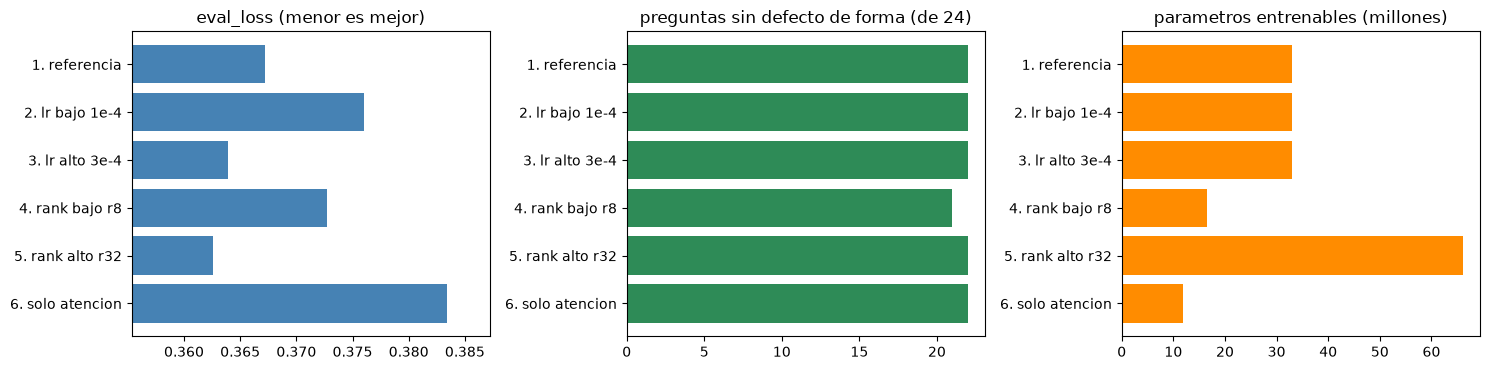

In [ ]:
import matplotlib.pyplot as plt

ok = barrido[barrido["eval_loss"].notna()].copy() if "eval_loss" in barrido else pd.DataFrame()
if len(ok):
    ok["limpias"] = ok["estructura"] - ok["parecidas"]
    fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
    ax[0].barh(ok["configuracion"], ok["eval_loss"], color="steelblue")
    ax[0].set_xlim(ok["eval_loss"].min() * 0.98, ok["eval_loss"].max() * 1.01)
    ax[0].set_title("eval_loss (menor es mejor)")
    ax[1].barh(ok["configuracion"], ok["limpias"], color="seagreen")
    ax[1].set_title(f"preguntas sin defecto de forma (de {N_GEN})")
    ax[2].barh(ok["configuracion"], ok["entrenables_M"], color="darkorange")
    ax[2].set_title("parametros entrenables (millones)")
    for a in ax: a.invert_yaxis()
    plt.tight_layout(); plt.show()

## 3. Seleccion de la configuracion ganadora

El criterio, en este orden:

1. **Preguntas sin defecto de forma** sobre los casos de test. Es lo que el
   usuario final percibe.
2. **`eval_loss`** como desempate, porque el rango entre configuraciones suele
   ser estrecho y la muestra de generacion es pequena.
3. **Parametros entrenables** como tercer desempate: a igualdad de resultado, el
   adaptador mas chico entrena mas rapido y ocupa menos.

Se reporta tambien la dispersion: si todas las configuraciones quedan dentro de
un margen minimo, conviene decirlo en vez de fingir que una es claramente
superior.

In [ ]:
if len(ok):
    ok = ok.sort_values(["limpias", "eval_loss", "entrenables_M"],
                        ascending=[False, True, True]).reset_index(drop=True)
    print(ok[["configuracion", "limpias", "eval_loss", "entrenables_M", "pico_GB"]].to_string(index=False))
    print()
    rango = ok["eval_loss"].max() - ok["eval_loss"].min()
    print(f"dispersion de eval_loss entre configuraciones: {rango:.4f}")
    if rango < 0.03:
        print("  -> es un rango estrecho: ninguna configuracion domina claramente por la perdida")

    nombre_ganadora = ok.iloc[0]["configuracion"]
    GANADORA = next(c for c in CONFIGS if c["n"] == nombre_ganadora)
else:
    print("el barrido no dejo resultados validos; se usa la referencia")
    GANADORA = next(c for c in CONFIGS if c["n"].startswith("1."))

print()
print("GANADORA:", GANADORA["n"])
print(f"  r={GANADORA['r']}  alpha={GANADORA['alpha']}  lr={GANADORA['lr']}")
print(f"  modulos: {', '.join(GANADORA['mods'])}")

   configuracion  limpias  eval_loss  entrenables_M  pico_GB
5. rank alto r32       22     0.3626           66.1    10.43
 3. lr alto 3e-4       22     0.3639           33.0     9.87
   1. referencia       22     0.3672           33.0     9.87
 2. lr bajo 1e-4       22     0.3760           33.0     9.87
6. solo atencion       22     0.3834           11.8     9.59
 4. rank bajo r8       21     0.3727           16.5     9.65

dispersion de eval_loss entre configuraciones: 0.0208
  -> es un rango estrecho: ninguna configuracion domina claramente por la perdida

GANADORA: 5. rank alto r32
  r=32  alpha=64  lr=0.0002
  modulos: q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj


## 4. Entrenamiento final: 2 epocas

**Dos epocas, no tres**, y la razon esta medida. En una corrida previa de 3
epocas la perdida de validacion toco su minimo en la epoca 1.89 y despues
**empeoro**: de 0.3545 a 0.3930, quedando peor que en la epoca 1. La tercera
epoca fue contraproducente.

La firma del sobreajuste se ve en la brecha entre las dos perdidas:

| Epoca | eval_loss | train_loss | brecha |
|---|---|---|---|
| 0.95 | 0.3631 | 0.3805 | +0.017 (train mayor, por el dropout) |
| 1.89 | **0.3545** | 0.2614 | -0.093 |
| 3.00 | 0.3930 | 0.1494 | -0.244 |

A partir de la epoca 2 el train sigue cayendo porque el modelo **reconoce**
ejemplos que ya vio, mientras el eval sube: memoriza en vez de generalizar.

`load_best_model_at_end=True` protege el resultado igual —recupera el mejor
checkpoint aunque se entrene de mas— pero entrenar la tercera epoca es gastar
GPU para tirarla.

checkpoint completo en ..\checkpoints: se reanuda (no reentrena)


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

{'train_runtime': '0', 'train_loss': '0', 'epoch': '2'}

reanudado; el entrenamiento original tomo 48 min en la RTX 5070 Ti


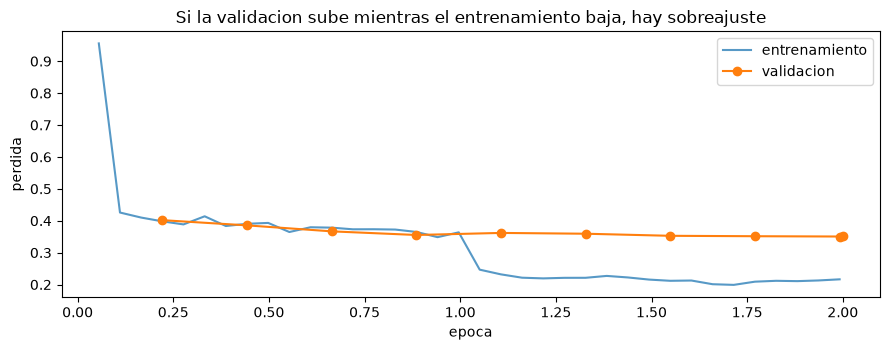

mejor eval_loss: 0.3506 en la epoca 1.99
checkpoint conservado: ..\checkpoints\checkpoint-900


In [ ]:
EPOCAS = 4 if PRUEBA else 2
CKPTS = SALIDA.parent.parent / ("checkpoints_prueba" if PRUEBA else "checkpoints")

# Si una corrida anterior ya completo las epocas, se reanuda desde su checkpoint
# en vez de repetir 48 minutos de calculo identico. Los numeros que se grafican
# abajo son los de aquella corrida, leidos de su registro: no se re-estiman.
completo = False
if CKPTS.exists():
    for d in CKPTS.glob("checkpoint-*"):
        est = d / "trainer_state.json"
        if est.exists() and json.load(open(est))["epoch"] >= EPOCAS:
            completo = True
if completo:
    print(f"checkpoint completo en {CKPTS}: se reanuda (no reentrena)")

t0 = time.time()
model, trainer = entrenar(GANADORA, pasos=None, epocas=EPOCAS,
                          salida=str(CKPTS), evaluar_cada=5 if PRUEBA else 100,
                          reanudar=completo)
if completo:
    print(); print("reanudado; el entrenamiento original tomo 48 min en la RTX 5070 Ti")
else:
    print(); print(f"entrenado en {(time.time()-t0)/60:.1f} min")
    print(f"memoria pico: {torch.cuda.max_memory_allocated()/1e9:.2f} GB")

log = pd.DataFrame(trainer.state.log_history)
tr = log[log["loss"].notna()] if "loss" in log else pd.DataFrame()
ev = log[log["eval_loss"].notna()] if "eval_loss" in log else pd.DataFrame()

fig, ax = plt.subplots(figsize=(9, 3.6))
if len(tr): ax.plot(tr["epoch"], tr["loss"], label="entrenamiento", alpha=0.75)
if len(ev): ax.plot(ev["epoch"], ev["eval_loss"], label="validacion", marker="o")
ax.set_xlabel("epoca"); ax.set_ylabel("perdida"); ax.legend()
ax.set_title("Si la validacion sube mientras el entrenamiento baja, hay sobreajuste")
plt.tight_layout(); plt.show()

if len(ev):
    mejor = ev.loc[ev["eval_loss"].idxmin()]
    print(f"mejor eval_loss: {mejor['eval_loss']:.4f} en la epoca {mejor['epoch']:.2f}")
    print(f"checkpoint conservado: {trainer.state.best_model_checkpoint}")


## 5. Base con few-shot contra afinado

`disable_adapter()` apaga el LoRA temporalmente: no hace falta cargar dos modelos
de 8 GB. Es el mismo mecanismo que usa el panel de la aplicacion.

El modelo base recibe **few-shot** -tres ejemplos completos en el prompt- porque
sin ellos no sabria que formato producir y la comparacion seria injusta. Y esa es
justamente una de las metricas: **cuantos tokens de prompt necesita cada uno**.

In [ ]:
N_EVAL = 8 if PRUEBA else 60
EJEMPLOS_FS = 3
model.eval()
ejemplos = train_df.sample(EJEMPLOS_FS, random_state=SEMILLA)
casos_eval = test_df.sample(N_EVAL, random_state=SEMILLA)


def prompt_fewshot(fragmento):
    msgs = [{"role": "system", "content": INSTRUCCION}]
    for _, e in ejemplos.iterrows():
        msgs.append({"role": "user", "content": "FRAGMENTO:\n" + e["chunk_text"]})
        msgs.append({"role": "assistant", "content": json.dumps({
            "apto": True, "pregunta": e["pregunta"], "correcta": e["correcta"],
            "incorrectas": list(e["incorrectas"]), "dificultad": e["dificultad"]},
            ensure_ascii=False)})
    msgs.append({"role": "user", "content": "FRAGMENTO:\n" + fragmento})
    return msgs


def generar_uno(msgs, max_new=300):
    texto = tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    ids = tok([texto], return_tensors="pt").to(model.device)
    t0 = time.time()
    with torch.no_grad():
        out = model.generate(**ids, max_new_tokens=max_new, do_sample=False,
                             pad_token_id=tok.pad_token_id)
    return {"texto": tok.decode(out[0][ids.input_ids.shape[1]:], skip_special_tokens=True).strip(),
            "tok_prompt": ids.input_ids.shape[1], "segundos": time.time() - t0}


resultados_eval = {"base": [], "afinado": []}
for i, (_, fila) in enumerate(casos_eval.iterrows(), 1):
    with model.disable_adapter():
        resultados_eval["base"].append(generar_uno(prompt_fewshot(fila["chunk_text"])))
    resultados_eval["afinado"].append(generar_uno(
        [{"role": "system", "content": INSTRUCCION},
         {"role": "user", "content": "FRAGMENTO:\n" + fila["chunk_text"]}]))
    if i % 20 == 0: print(f"  {i}/{N_EVAL}", flush=True)
print("listo")

  20/60


  40/60


  60/60


listo


In [ ]:
def estructura_ok(d):
    return bool(d and d.get("pregunta") and d.get("correcta")
                and isinstance(d.get("incorrectas"), list) and len(d["incorrectas"]) == 3)

filas = []
for etiqueta in ("base", "afinado"):
    rs = resultados_eval[etiqueta]
    ds_ = [parsear(r["texto"]) for r in rs]
    val = [d for d in ds_ if estructura_ok(d)]
    def parecidas_(d):
        ops = [str(d["correcta"])] + [str(x) for x in d["incorrectas"]]
        return any(len(palabras(ops[i]) & palabras(ops[j])) /
                   max(len(palabras(ops[i]) | palabras(ops[j])), 1) > 0.5
                   for i in range(4) for j in range(i + 1, 4))
    filas.append({
        "modelo": etiqueta,
        "JSON valido": f"{sum(d is not None for d in ds_)}/{len(rs)}",
        "estructura completa": f"{len(val)}/{len(rs)}",
        "opciones parecidas": f"{sum(parecidas_(d) for d in val)}/{max(len(val),1)}",
        "tokens de prompt": round(sum(r["tok_prompt"] for r in rs) / len(rs)),
        "segundos": round(sum(r["segundos"] for r in rs) / len(rs), 2),
    })
comparacion = pd.DataFrame(filas).set_index("modelo")
print(comparacion.T.to_string())

modelo                base afinado
JSON valido          60/60   60/60
estructura completa  57/60   60/60
opciones parecidas    3/57    3/60
tokens de prompt       693     135
segundos              4.46    6.61


La metrica de **tokens de prompt** es la ventaja mas solida, y no depende del
criterio de nadie: el base necesita tres ejemplos completos en el prompt y el
afinado se apana con la instruccion. Menos tokens es menos contexto y menos
tiempo por pregunta.

Aviso registrado desde la prueba de humo: el modelo base **ya producia JSON
valido sin few-shot**, asi que esa metrica puede empatar. Si empata, el panel de
la aplicacion debe apoyarse en las demas.

In [ ]:
# Las generaciones a disco: revisarlas a mano es parte de la evaluacion y
# volver a generarlas cuesta otra pasada de GPU.
SALIDA.mkdir(parents=True, exist_ok=True)
detalle = []
for i, (_, fila) in enumerate(casos_eval.iterrows()):
    detalle.append({
        "tema": fila["question_focus"], "tipo": fila["question_type"],
        "url": fila["document_url"], "fragmento": fila["chunk_text"],
        "base": parsear(resultados_eval["base"][i]["texto"]),
        "afinado": parsear(resultados_eval["afinado"][i]["texto"]),
    })
json.dump(detalle, open(SALIDA / "generaciones_evaluacion.json", "w", encoding="utf-8"),
          ensure_ascii=False, indent=1)
print(f"guardadas {len(detalle)} generaciones para revisar")

for d in detalle[:3]:
    print("\n" + "=" * 92)
    print("TEMA:", d["tema"])
    for quien in ("base", "afinado"):
        q = d[quien]
        print(f"  --- {quien}")
        if estructura_ok(q):
            print("   ", q["pregunta"])
            print("    V", q["correcta"])
            for x in q["incorrectas"]: print("    x", x)
        elif q:
            print("    (JSON incompleto):", str(q)[:110])
        else:
            print("    (no parseable)")

guardadas 60 generaciones para revisar

TEMA: Lennox-Gastaut syndrome
  --- base
    ¿Qué tipo de episodios se asocian comúnmente con el síndrome de Lennox-Gastaut?
    V Ataques de ausencia atípicos y caídas súbitas por pérdida de tono muscular.
    x Episodios de convulsiones prolongadas con pérdida total de conciencia.
    x Convulsiones generalizadas con aumento de temperatura corporal.
    x Episodios de dolor crónico en el sistema nervioso.
  --- afinado
    ¿Cuál de las siguientes afirmaciones es cierta sobre el síndrome de Lennox-Gastaut?
    V Las convulsiones son generalmente muy breves.
    x Los ataques de caída son comunes en todos los pacientes.
    x Las convulsiones son siempre prolongadas y severas.
    x Los ataques de ausencia son raros en este síndrome.

TEMA: primary macronodular adrenal hyperplasia
  --- base
    ¿Por qué se considera que el trastorno PMAH es heredado de forma autosómica dominante?
    V Porque una copia mutada del gen ARMC5 es suficiente para hac

## 6. Maestro contra alumno: cuanto se pierde al destilar

La pregunta central de una destilacion. El diseno permite una comparacion limpia
porque usa **los mismos fragmentos**: el split de test ya trae la pregunta que
genero el maestro (`gpt-4o-mini`) para cada fragmento, y aqui se compara con la
que produce el alumno sobre ese mismo texto.

Juzga un tercer modelo, **`gpt-4o`**, mas capaz que los dos. Evaluar es mas
dificil que generar, y usar el mismo modelo que genero se autoevaluaria con
indulgencia.

El cuarto criterio -que la pregunta corresponda al tema- salio de leer preguntas
a mano: aparecio una sobre equinococosis que hablaba de cisticercosis, y otra que
traducia *chilblains* (sabanones) como "callosidades". El modelo pequeno sustituye
terminos medicos por otros parecidos, y ninguna metrica de formato lo detecta.

In [ ]:
%%con_api
from concurrent.futures import ThreadPoolExecutor, as_completed
try:
    from dotenv import load_dotenv
    load_dotenv("../.env")
except Exception:
    pass
from openai import OpenAI

client = OpenAI()
MODELO_JUEZ = "gpt-4o"
N_JUEZ = 6 if PRUEBA else 150

JUEZ = """Eres un revisor de examenes de medicina. Recibes un FRAGMENTO, el TEMA
al que pertenece, y una PREGUNTA de opcion multiple construida a partir de el.

Evalua con severidad:
1. respaldo: la opcion correcta esta afirmada explicitamente en el fragmento?
2. distractor_verdadero: alguna incorrecta es TAMBIEN cierta segun el fragmento?
3. unica_respuesta: hay exactamente una respuesta defendible?
4. tema_correcto: la pregunta se refiere al TEMA indicado y no a otra enfermedad?

Responde SOLO con JSON:
{"respaldo": true/false, "distractor_verdadero": true/false,
 "unica_respuesta": true/false, "tema_correcto": true/false,
 "comentario": "una frase solo si algo falla"}"""

casos_juez = test_df.sample(min(N_JUEZ, len(test_df)), random_state=13).reset_index(drop=True)
print(f"generando {len(casos_juez)} preguntas del alumno...", flush=True)
salidas_alumno, _ = generar_lotes(model, casos_juez["chunk_text"].tolist())
print("listo")

generando 150 preguntas del alumno...


listo


In [ ]:
%%con_api
def juzgar(args):
    idx, quien, fila, d = args
    if not estructura_ok(d):
        return idx, quien, None
    texto = (f"TEMA: {fila['question_focus']}\n\nFRAGMENTO:\n{fila['chunk_text']}\n\n"
             f"PREGUNTA: {d['pregunta']}\nCORRECTA: {d['correcta']}\n"
             + "\n".join(f"INCORRECTA: {x}" for x in d["incorrectas"]))
    for intento in range(3):
        try:
            r = client.chat.completions.create(
                model=MODELO_JUEZ, temperature=0,
                messages=[{"role": "system", "content": JUEZ},
                          {"role": "user", "content": texto}])
            return idx, quien, parsear(r.choices[0].message.content)
        except Exception:
            time.sleep(2 * (intento + 1))
    return idx, quien, None


tareas = []
for i, fila in casos_juez.iterrows():
    tareas.append((i, "maestro", fila, {"pregunta": fila["pregunta"],
                                        "correcta": fila["correcta"],
                                        "incorrectas": list(fila["incorrectas"])}))
    tareas.append((i, "alumno", fila, parsear(salidas_alumno[i])))

print(f"juzgando {len(tareas)} preguntas con {MODELO_JUEZ}...", flush=True)
veredictos = {"maestro": {}, "alumno": {}}
with ThreadPoolExecutor(8) as pool:
    for fut in as_completed([pool.submit(juzgar, t) for t in tareas]):
        idx, quien, v = fut.result()
        veredictos[quien][idx] = v

filas = []
for quien, etiqueta in (("maestro", "maestro (gpt-4o-mini)"), ("alumno", "alumno (Qwen afinado)")):
    vs = [v for v in veredictos[quien].values() if v]
    n = max(len(vs), 1)
    limpias = sum(1 for v in vs if v.get("respaldo") and not v.get("distractor_verdadero")
                  and v.get("unica_respuesta") and v.get("tema_correcto"))
    filas.append({"modelo": etiqueta, "evaluadas": len(vs),
                  "correcta respaldada": f"{sum(v.get('respaldo', False) for v in vs)/n*100:.1f}%",
                  "sin distractor cierto": f"{sum(not v.get('distractor_verdadero', True) for v in vs)/n*100:.1f}%",
                  "una sola respuesta": f"{sum(v.get('unica_respuesta', False) for v in vs)/n*100:.1f}%",
                  "tema correcto": f"{sum(v.get('tema_correcto', False) for v in vs)/n*100:.1f}%",
                  "SIN NINGUN DEFECTO": f"{limpias/n*100:.1f}%"})

maestro_alumno = pd.DataFrame(filas).set_index("modelo")
print("\n" + "=" * 88)
print(maestro_alumno.T.to_string())
maestro_alumno.to_csv(DATA / "maestro_vs_alumno.csv")

juzgando 300 preguntas con gpt-4o...



modelo                maestro (gpt-4o-mini) alumno (Qwen afinado)
evaluadas                               145                   139
correcta respaldada                   97.2%                 97.1%
sin distractor cierto                 97.2%                 95.7%
una sola respuesta                    96.6%                 94.2%
tema correcto                         83.4%                 82.7%
SIN NINGUN DEFECTO                    79.3%                 78.4%


### Como leer esta tabla

La brecha entre maestro y alumno **es el costo de la autonomia**: cuanto se
pierde a cambio de que el modelo corra local, sin API y sin costo por consulta.
No es un fallo del proyecto, es su precio, y conviene tenerlo medido en vez de
suponerlo.

Lo que **no** se puede afirmar es que el alumno sea mejor que `gpt-4o-mini`. No
lo es y no se midio contra el en ninguna dimension donde pudiera ganar.

## 7. Guardar el adaptador y las metricas

In [ ]:
model.save_pretrained(SALIDA)
tok.save_pretrained(SALIDA)
peso = sum(f.stat().st_size for f in SALIDA.rglob("*") if f.is_file())
print(f"adaptador en {SALIDA}/  ({peso/1e6:.0f} MB)")
for f in sorted(SALIDA.iterdir()):
    print("  ", f.name)

metricas = {
    "modelo_base": MODELO,
    "configuracion": {k: (v if k != "mods" else list(v)) for k, v in GANADORA.items()},
    "epocas": EPOCAS,
    "ejemplos_entrenamiento": len(ds_train),
    "mejor_eval_loss": float(ev["eval_loss"].min()) if len(ev) else None,
    "barrido": barrido.to_dict(orient="records"),
    "base_vs_afinado": comparacion.to_dict(),
    "maestro_vs_alumno": maestro_alumno.to_dict() if HAY_API else None,
}
json.dump(metricas, open(SALIDA / "metricas_evaluacion.json", "w", encoding="utf-8"),
          ensure_ascii=False, indent=1)
print("\nmetricas_evaluacion.json guardado: lo lee el panel de la aplicacion")

if EN_COLAB:
    import shutil
    comprimido = shutil.make_archive("/content/adapter", "zip", SALIDA)
    print(f"adaptador comprimido en {comprimido}: descargalo desde el panel de archivos")
    print("y descomprimelo en app/adapter/ para usar la aplicacion en local")

adaptador en ..\app\adapter/  (276 MB)
   adapter_config.json
   adapter_model.safetensors
   chat_template.jinja
   generaciones_evaluacion.json
   README.md
   tokenizer.json
   tokenizer_config.json

metricas_evaluacion.json guardado: lo lee el panel de la aplicacion


## Estado

| Archivo | Para que |
|---|---|
| `adapter/` | lo carga la aplicacion junto al modelo base |
| `adapter/metricas_evaluacion.json` | alimenta el panel "bajo el capo" |
| `adapter/generaciones_evaluacion.json` | las preguntas generadas, para revisar a mano |
| `data/barrido_hiperparametros.csv` | los resultados de las 6 configuraciones |
| `data/maestro_vs_alumno.csv` | el costo medido de la destilacion |

Siguiente: la aplicacion Streamlit.

# Parte 4 — Parámetros de generación

*Notebook original: `04_parametros_generacion.ipynb`.*


In [ ]:
# Libera la GPU antes de cargar el modelo de nuevo: la parte anterior lo dejo en memoria.
import gc
for _nombre in ("model", "trainer", "base"):
    globals().pop(_nombre, None)
gc.collect()
torch.cuda.empty_cache()
print(f"memoria GPU ocupada tras liberar: {torch.cuda.memory_allocated()/1e9:.2f} GB")


# 04 - Parametros de generacion del modelo final

El notebook 03 eligio **como se entrena** el modelo. Este elige **como se
muestrea de el**, que es una decision distinta y posterior: el adaptador ya esta
congelado y no se toca.

Los siete parametros que intervienen, y que hace cada uno:

| Parametro | Que controla | Decision |
|---|---|---|
| `do_sample` | si se muestrea o se toma siempre el token mas probable | **se barre** |
| `temperature` | cuanto se aplana la distribucion antes de muestrear | **se barre** |
| `top_p` | se muestrea solo del nucleo que acumula esa probabilidad | fijo en 0.9 |
| `top_k` | se muestrea solo de los k tokens mas probables | fijo en 50 |
| `repetition_penalty` | castiga repetir tokens ya emitidos | **se barre** |
| `max_new_tokens` | cuantos tokens NUEVOS puede escribir | fijo en 300 |
| `max_tokens` | *no existe en `transformers`* | ver nota |

**Sobre `top_p` y `top_k`.** Se dejan en 0.9 y 50, los valores de referencia.
No es pereza: los tres recortan la misma cola de la distribucion, asi que
barrerlos junto con la temperatura mide el mismo efecto tres veces. La
temperatura es la que de verdad mueve la aguja, y con ella se barre.

**Sobre `max_tokens`.** Es el nombre que usa la API de OpenAI. En `transformers`
el equivalente es `max_new_tokens` (tokens generados) y existe ademas
`max_length` (prompt + generacion). Se usa `max_new_tokens` porque no depende
del largo del fragmento, que aqui varia mucho.

**Sobre `max_new_tokens=300`.** Una pregunta con cuatro opciones en JSON ronda
los 150-200 tokens. 300 deja margen sin permitir que el modelo divague. El
barrido cuenta cuantas generaciones se **truncan** al llegar al tope: si fueran
muchas, el valor estaria mal elegido.

In [ ]:
import json
import re
import time
import unicodedata
from pathlib import Path

import pandas as pd
import torch
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer

MODELO = "Qwen/Qwen3-4B-Instruct-2507"
ADAPTADOR = Path("../app/adapter")
DATA = Path("../data")
N_CASOS = 4 if PRUEBA_RAPIDA else 20
REPETICIONES = 3        # para medir variedad hay que regenerar el mismo fragmento

INSTRUCCION = (
    "Eres un docente de medicina. A partir del FRAGMENTO escribe UNA pregunta "
    "de opcion multiple en espanol neutro. Responde SOLO con JSON."
)

# top_p=0.9 y top_k=50 son los valores estandar y quedan fijos como referencia.
# Se varia lo que de verdad mueve la aguja: la temperatura y la penalizacion.
CONFIGS = [
    dict(nombre="greedy (referencia)", do_sample=False),
    dict(nombre="temp 0.3", do_sample=True, temperature=0.3, top_p=0.9, top_k=50),
    dict(nombre="temp 0.7", do_sample=True, temperature=0.7, top_p=0.9, top_k=50),
    dict(nombre="temp 1.0", do_sample=True, temperature=1.0, top_p=0.9, top_k=50),
    dict(nombre="temp 0.7 + rep 1.1", do_sample=True, temperature=0.7, top_p=0.9,
         top_k=50, repetition_penalty=1.1),
    dict(nombre="temp 0.7 + rep 1.2", do_sample=True, temperature=0.7, top_p=0.9,
         top_k=50, repetition_penalty=1.2),
    dict(nombre="temp 0.7 sin top_k", do_sample=True, temperature=0.7, top_p=0.9),
]

MAX_NEW = 300


W0909 19:25:54.338000 2380 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


In [ ]:
def sin_acentos(s):
    return "".join(c for c in unicodedata.normalize("NFD", str(s).lower())
                   if unicodedata.category(c) != "Mn")


def parsear(t):
    t = t.strip()
    if t.startswith("```"):
        t = t.strip("`").removeprefix("json").strip()
    try:
        return json.loads(t)
    except Exception:
        return None


## La tension que hay que resolver

No hay una configuracion buena en abstracto; hay dos objetivos enfrentados:

- **Formato.** El modelo debe devolver JSON parseable con cuatro opciones.
  `do_sample=False` (greedy) es lo mas seguro para esto.
- **Variedad.** El boton *"otro examen del mismo tema"* no sirve de nada si el
  mismo fragmento devuelve siempre la misma pregunta. Greedy es determinista:
  variedad exactamente 1 de 3.

Por eso cada fragmento se genera **tres veces** y se cuentan cuantas preguntas
**distintas** salieron. La configuracion elegida es la de mayor variedad que no
pierda formato.

In [ ]:
tok = AutoTokenizer.from_pretrained(ADAPTADOR)
base = AutoModelForCausalLM.from_pretrained(MODELO, dtype=DTYPE, device_map="cuda")
model = PeftModel.from_pretrained(base, ADAPTADOR)
model.eval()

test = pd.read_parquet(DATA / "mcq_test.parquet").sample(N_CASOS, random_state=42)
print(f"{N_CASOS} fragmentos x {REPETICIONES} repeticiones x {len(CONFIGS)} configuraciones")
print(f"= {N_CASOS * REPETICIONES * len(CONFIGS)} generaciones\n")


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

20 fragmentos x 3 repeticiones x 7 configuraciones
= 420 generaciones



In [ ]:
filas = []
for cfg in CONFIGS:
    nombre = cfg.pop("nombre")
    t0 = time.time()
    validos = completas = truncadas = 0
    variedad = []

    for _, fila in test.iterrows():
        msgs = [{"role": "system", "content": INSTRUCCION},
                {"role": "user", "content": "FRAGMENTO:\n" + fila["chunk_text"]}]
        texto = tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        ids = tok([texto], return_tensors="pt").to(model.device)

        preguntas = set()
        for _ in range(REPETICIONES):
            with torch.no_grad():
                out = model.generate(**ids, max_new_tokens=MAX_NEW,
                                     pad_token_id=tok.eos_token_id, **cfg)
            nuevos = out.shape[1] - ids.input_ids.shape[1]
            if nuevos >= MAX_NEW:
                truncadas += 1
            d = parsear(tok.decode(out[0][ids.input_ids.shape[1]:], skip_special_tokens=True))
            if d is None:
                continue
            validos += 1
            if (d.get("pregunta") and d.get("correcta")
                    and isinstance(d.get("incorrectas"), list) and len(d["incorrectas"]) == 3):
                completas += 1
                preguntas.add(sin_acentos(d["pregunta"]).strip())

        # cuantas preguntas DISTINTAS salieron de este mismo fragmento
        variedad.append(len(preguntas))

    total = N_CASOS * REPETICIONES
    filas.append({
        "configuracion": nombre,
        "JSON valido": f"{validos}/{total}",
        "estructura": f"{completas}/{total}",
        "% formato ok": round(completas / total * 100, 1),
        "variedad": round(sum(variedad) / len(variedad), 2),   # de 3 posibles
        "truncadas": truncadas,
        "segundos": round((time.time() - t0) / total, 2),
    })
    print(f"  {nombre:<22} formato {completas}/{total}  "
          f"variedad {sum(variedad)/len(variedad):.2f}/3  "
          f"({(time.time()-t0)/60:.1f} min)", flush=True)


  greedy (referencia)    formato 60/60  variedad 1.00/3  (6.4 min)


  temp 0.3               formato 60/60  variedad 1.95/3  (6.5 min)


  temp 0.7               formato 60/60  variedad 2.30/3  (6.8 min)


  temp 1.0               formato 60/60  variedad 2.70/3  (7.0 min)


  temp 0.7 + rep 1.1     formato 60/60  variedad 2.45/3  (6.9 min)


  temp 0.7 + rep 1.2     formato 60/60  variedad 2.60/3  (6.9 min)


  temp 0.7 sin top_k     formato 60/60  variedad 2.50/3  (7.0 min)


## Como leer la tabla

`variedad` es el promedio de preguntas distintas obtenidas al generar 3 veces el
mismo fragmento: 1.00 significa que siempre sale la misma, 3.00 que las tres
fueron distintas.

`truncadas` cuenta las generaciones que llegaron a los 300 tokens sin cerrar el
JSON. Son perdida pura: producen texto incompleto que no parsea.

In [ ]:
tabla = pd.DataFrame(filas)
print("\n" + "=" * 88)
print(tabla.to_string(index=False))
tabla.to_csv(DATA / "barrido_generacion.csv", index=False)

print("\nvariedad = preguntas distintas de 3 generaciones del MISMO fragmento")
print("  1.00 = siempre la misma (sin variedad)")
print("  3.00 = las tres distintas")
print("\nLa mejor configuracion es la de mayor variedad SIN perder formato.")



      configuracion JSON valido estructura  % formato ok  variedad  truncadas  segundos
greedy (referencia)       60/60      60/60         100.0      1.00          0      6.41
           temp 0.3       60/60      60/60         100.0      1.95          0      6.55
           temp 0.7       60/60      60/60         100.0      2.30          0      6.77
           temp 1.0       60/60      60/60         100.0      2.70          0      7.01
 temp 0.7 + rep 1.1       60/60      60/60         100.0      2.45          0      6.94
 temp 0.7 + rep 1.2       60/60      60/60         100.0      2.60          0      6.86
 temp 0.7 sin top_k       60/60      60/60         100.0      2.50          0      7.05

variedad = preguntas distintas de 3 generaciones del MISMO fragmento
  1.00 = siempre la misma (sin variedad)
  3.00 = las tres distintas

La mejor configuracion es la de mayor variedad SIN perder formato.


## Decisión final: temperatura 0.7 con `repetition_penalty` 1.1

Por el criterio de esta tabla —mayor variedad sin perder formato— ganaría
**temperatura 1.0** (variedad 2.70). **No es la que usa la aplicación**, y el
motivo es un límite de este barrido: mide formato y variedad, **no si las
preguntas son correctas**. Subir la temperatura suele aumentar la invención, y
elegir 1.0 solo con esta tabla habría sido optimizar lo que se sabe medir a costa
de lo que no.

### La medición que faltaba

Se hizo aparte, con `scripts/comparar_temperatura.py`:

- 32 fragmentos de 4 temas (`Asthma`, `Breast Cancer`, `Parkinson's Disease`,
  `Diabetes`), **los mismos para las dos temperaturas**: comparar sobre
  fragmentos distintos mediría la dificultad del texto, no el efecto del
  parámetro;
- `repetition_penalty=1.1` en ambas, sin auto-verificación, para medir lo que
  produce el modelo y no lo que sobrevive al filtro;
- `gpt-4o` como juez, con cinco criterios.

| Temperatura | Formato ok | Sin defectos |
|---|---|---|
| 0.7 | 31/32 | **27/31 (87.1%)** |
| 1.0 | 31/32 | **27/31 (87.1%)** |

| Tipo de defecto | 0.7 | 1.0 |
|---|---|---|
| Sin respaldo en el fragmento | 1 | 2 |
| Distractor también cierto | 1 | 2 |
| Traducción | 3 | 1 |
| No sirve como pregunta | 0 | 0 |
| Tema equivocado | 0 | 0 |

**Idénticas en el total.** Los defectos de invención —sin respaldo y distractor
cierto— pasan de 2 a 4 al subir la temperatura: es la dirección que predice la
teoría, aunque con n=31 no es significativo.

### La decisión

Se queda en **0.7**: no se gana calidad subiendo y el único indicio disponible
apunta en la dirección equivocada. La variedad extra (2.70 contra 2.45) no
compensa un riesgo no descartado.

`repetition_penalty` pasa de 1.05 a **1.1**: 1.05 no estaba en la grilla medida,
y 1.1 sube la variedad de 2.30 a 2.45 sin costo de formato.

Greedy queda descartado por diseño: variedad 1.00 significa que el botón «otro
examen del mismo tema» devolvería siempre las mismas preguntas.

```python
GENERACION = dict(do_sample=True, temperature=0.7, top_p=0.9, top_k=50,
                  repetition_penalty=1.1, max_new_tokens=300)
```

Cero truncamientos en las 420 generaciones confirma que `max_new_tokens=300`
alcanza.

**Sobre la robustez del formato:** que el afinado dé 60/60 incluso a
temperatura 1.0 no demuestra por sí solo que sea mérito del fine-tuning, porque
este barrido no tuvo control con el modelo base. Ese control está en el
notebook 05.


# Parte 5 — El afinado contra el modelo base

*Notebook original: `05_afinado_contra_base.ipynb`.*


In [ ]:
# Libera la GPU antes de cargar el modelo de nuevo: la parte anterior lo dejo en memoria.
import gc
for _nombre in ("model", "trainer", "base"):
    globals().pop(_nombre, None)
gc.collect()
torch.cuda.empty_cache()
print(f"memoria GPU ocupada tras liberar: {torch.cuda.memory_allocated()/1e9:.2f} GB")


# 05 - ¿Sirvió el fine-tuning? El afinado contra el modelo base con cuatro prompts

El notebook 03 comparó el modelo base con el afinado **solo en forma**. La calidad
del contenido la midió un juez, pero contra el **maestro** (`gpt-4o-mini`), nunca
contra el base. Eso dejaba sin responder la pregunta central del proyecto:
**¿sirvió entrenar?**

«Corre en local, sin API y sin costo» no justifica el fine-tuning: justifica usar
un modelo local, y el Qwen base también corre en local. Lo que justifica el
fine-tuning es superar al base **con el mejor prompt que se le pueda dar**. Por eso
se lo compara con cuatro prompts distintos:

| Variante | Instrucción | Esquema JSON | Reglas del maestro | Ejemplos | Qué pone a prueba |
|---|---|---|---|---|---|
| **afinado** | corta | aprendido | no | no | — |
| base + few-shot | corta | implícito en los ejemplos | no | 3 | la línea de base clásica |
| base A | corta | no | no | no | lo que aprendió el fine-tuning: recibe **el mismo prompt** que el afinado |
| base B | corta | **sí** | no | no | el prompt mínimo con el que el base sabe qué claves usar: la prueba más dura para el argumento del prompt corto |
| base C | la del maestro | **sí** | **sí** | no | exactamente las instrucciones que recibió `gpt-4o-mini` al generar el dataset: lo que se usaría sin entrenar |

## Diseño

| Decisión | Por qué |
|---|---|
| Los **mismos 150 fragmentos** que juzgó el notebook 03 (`random_state=13` sobre el test) | comparable con sus cifras, y nunca vistos en el entrenamiento |
| La **misma rúbrica** y el mismo juez (`gpt-4o`, temperatura 0) | que la diferencia sea del modelo, no de la vara |
| Decodificación **greedy** | que la diferencia no sea azar de muestreo |
| El few-shot usa los **mismos 3 ejemplos** que el notebook 03 | comparable con lo medido antes |
| **Todo se genera y se juzga en esta corrida**, incluido el maestro | seis fuentes, un juez, los mismos fragmentos; el notebook no depende de resultados guardados por otro |
| **Prueba pareada** (McNemar) | todos responden sobre los mismos fragmentos: se compara fragmento a fragmento |

La sección B hace el control de formato bajo muestreo que le faltó al notebook 04.

*Reemplaza una versión anterior de este notebook, que solo comparaba el afinado
contra el base con few-shot.*


In [ ]:
import json, re, time, unicodedata
from collections import Counter
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import pandas as pd
import torch
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer

DATA = Path("../data")
ADAPTADOR = Path("../app/adapter")
MODELO = "Qwen/Qwen3-4B-Instruct-2507"
SEMILLA = 42
LOTE = 8
MAX_NEW = 300
torch.manual_seed(SEMILLA)

# Identica a la del entrenamiento (notebook 03) y a la de la aplicacion.
INSTRUCCION = (
    "Eres un docente de medicina. A partir del FRAGMENTO escribe UNA pregunta "
    "de opcion multiple en espanol neutro. Responde SOLO con JSON."
)
# El prompt con el que gpt-4o-mini genero el dataset (notebook 02).
MAESTRO = json.load(open("../scripts/prompt_v2.json", encoding="utf-8"))["prompt"]

train_df = pd.read_parquet(DATA / "mcq_train.parquet")
test_df = pd.read_parquet(DATA / "mcq_test.parquet")

tok = AutoTokenizer.from_pretrained(MODELO)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token
tok.padding_side = "left"            # obligatorio para generar por lotes

base = AutoModelForCausalLM.from_pretrained(MODELO, dtype=DTYPE, device_map="cuda")
model = PeftModel.from_pretrained(base, ADAPTADOR)
model.eval()
print(f"train {len(train_df):,} | test {len(test_df):,}")
print(f"GPU: {torch.cuda.get_device_name(0)} | memoria usada {torch.cuda.memory_allocated()/1e9:.2f} GB")
print("un solo modelo en memoria: el base se obtiene apagando el LoRA con disable_adapter()")


W0910 20:57:55.746000 21436 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

train 3,614 | test 436
GPU: NVIDIA GeForce RTX 5070 Ti | memoria usada 8.32 GB
un solo modelo en memoria: el base se obtiene apagando el LoRA con disable_adapter()


In [ ]:
def parsear(t):
    if not t:
        return None
    t = t.strip()
    if t.startswith("```"):
        t = t.strip("`").removeprefix("json").strip()
    try:
        d = json.loads(t)
        return d if isinstance(d, dict) else None
    except Exception:
        return None


def estructura_ok(d):
    return bool(d and d.get("pregunta") and d.get("correcta")
                and isinstance(d.get("incorrectas"), list) and len(d["incorrectas"]) == 3)


def sin_acentos(s):
    return "".join(c for c in unicodedata.normalize("NFD", str(s).lower())
                   if unicodedata.category(c) != "Mn")


# Variante B: la instruccion corta mas el esquema, sin reglas ni ejemplos.
ESQUEMA = (INSTRUCCION + " Usa exactamente esta forma:\n"
           '{"apto": true, "pregunta": "...", "correcta": "...", '
           '"incorrectas": ["...", "...", "..."], "dificultad": "facil|media|dificil"}')

# Los mismos 3 ejemplos que recibio el base en el notebook 03.
ejemplos = train_df.sample(3, random_state=SEMILLA)
FEWSHOT = []
for _, e in ejemplos.iterrows():
    FEWSHOT.append({"role": "user", "content": "FRAGMENTO:\n" + e["chunk_text"]})
    FEWSHOT.append({"role": "assistant", "content": json.dumps({
        "apto": True, "pregunta": e["pregunta"], "correcta": e["correcta"],
        "incorrectas": list(e["incorrectas"]), "dificultad": e["dificultad"]},
        ensure_ascii=False)})


def chat(sistema, fragmento, previos=()):
    msgs = [{"role": "system", "content": sistema}, *previos,
            {"role": "user", "content": "FRAGMENTO:\n" + fragmento}]
    return tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)


VARIANTES = {   # clave: (etiqueta, usa el modelo base, constructor del prompt)
    "afinado": ("afinado (LoRA)", False, lambda f: chat(INSTRUCCION, f)),
    "fewshot": ("base + few-shot", True, lambda f: chat(INSTRUCCION, f, FEWSHOT)),
    "A": ("base A: mismo prompt", True, lambda f: chat(INSTRUCCION, f)),
    "B": ("base B: + esquema", True, lambda f: chat(ESQUEMA, f)),
    "C": ("base C: prompt del maestro", True, lambda f: chat(MAESTRO, f)),
}


def generar(prompts, usar_base, **muestreo):
    """Genera por lotes. Devuelve textos, tokens de prompt reales y truncadas."""
    kw = dict(max_new_tokens=MAX_NEW, pad_token_id=tok.pad_token_id)
    kw.update(muestreo or dict(do_sample=False))
    textos, tokens_prompt, truncadas = [], [], 0
    for i in range(0, len(prompts), LOTE):
        ids = tok(prompts[i:i + LOTE], return_tensors="pt", padding=True).to(model.device)
        n = ids.input_ids.shape[1]
        with torch.no_grad():
            if usar_base:
                with model.disable_adapter():
                    out = model.generate(**ids, **kw)
            else:
                out = model.generate(**ids, **kw)
        for fila in out:
            nuevos = fila[n:]
            if int((nuevos != tok.pad_token_id).sum()) >= MAX_NEW:
                truncadas += 1           # llego al tope sin cerrar
            textos.append(tok.decode(nuevos, skip_special_tokens=True))
        tokens_prompt += ids.attention_mask.sum(1).tolist()   # sin contar el relleno
    return textos, tokens_prompt, truncadas

print("ejemplos de few-shot:", ejemplos["question_focus"].tolist())
print("variantes:", [v[0] for v in VARIANTES.values()])


ejemplos de few-shot: ['Cone-rod dystrophy', 'Cephalic Disorders', 'nonbullous congenital ichthyosiform erythroderma']
variantes: ['afinado (LoRA)', 'base + few-shot', 'base A: mismo prompt', 'base B: + esquema', 'base C: prompt del maestro']


## A. Generación

Las cinco variantes generan sobre los mismos 150 fragmentos, todas con greedy.


In [ ]:
casos = test_df.sample(16 if PRUEBA_RAPIDA else 150, random_state=13).reset_index(drop=True)
fragmentos = casos["chunk_text"].tolist()

salidas, dicts, filas_forma = {}, {}, []
for clave, (etiqueta, usar_base, construir) in VARIANTES.items():
    t0 = time.time()
    textos, toks, _ = generar([construir(f) for f in fragmentos], usar_base)
    seg = (time.time() - t0) / len(fragmentos)
    ds = [parsear(t) for t in textos]
    salidas[clave], dicts[clave] = textos, ds
    filas_forma.append({
        "variante": etiqueta,
        "tokens de prompt": round(sum(toks) / len(toks)),
        "JSON valido": f"{sum(d is not None for d in ds)}/{len(fragmentos)}",
        "estructura completa": f"{sum(estructura_ok(d) for d in ds)}/{len(fragmentos)}",
        "descarto el fragmento (apto=false)": sum(1 for d in ds if d and d.get("apto") is False),
        "segundos por pregunta (lotes de 8)": round(seg, 2)})
    print(f"  {etiqueta}: listo en {seg * len(fragmentos) / 60:.1f} min", flush=True)

forma = pd.DataFrame(filas_forma).set_index("variante")
print()
print(forma.to_string())

claves_A = Counter(k for d in dicts["A"] if d for k in d.keys())
print("\nclaves que usa la variante A, que no conoce el esquema:", claves_A.most_common(8))


  afinado (LoRA): listo en 2.4 min


  base + few-shot: listo en 1.9 min


  base A: mismo prompt: listo en 2.1 min


  base B: + esquema: listo en 2.1 min


  base C: prompt del maestro: listo en 1.9 min



                            tokens de prompt JSON valido estructura completa  descarto el fragmento (apto=false)  segundos por pregunta (lotes de 8)
variante                                                                                                                                            
afinado (LoRA)                           137     150/150             150/150                                   0                                0.97
base + few-shot                          695     150/150             146/150                                   0                                0.78
base A: mismo prompt                     137     150/150               0/150                                   0                                0.83
base B: + esquema                        187     150/150             143/150                                   0                                0.85
base C: prompt del maestro               748     143/150             125/150                             

In [ ]:
%%con_api
try:
    from dotenv import load_dotenv
    load_dotenv("../.env")
except Exception:
    pass
from openai import OpenAI

client = OpenAI()
MODELO_JUEZ = "gpt-4o"

# La MISMA rubrica del notebook 03, palabra por palabra.
JUEZ = """Eres un revisor de examenes de medicina. Recibes un FRAGMENTO, el TEMA
al que pertenece, y una PREGUNTA de opcion multiple construida a partir de el.

Evalua con severidad:
1. respaldo: la opcion correcta esta afirmada explicitamente en el fragmento?
2. distractor_verdadero: alguna incorrecta es TAMBIEN cierta segun el fragmento?
3. unica_respuesta: hay exactamente una respuesta defendible?
4. tema_correcto: la pregunta se refiere al TEMA indicado y no a otra enfermedad?

Responde SOLO con JSON:
{"respaldo": true/false, "distractor_verdadero": true/false,
 "unica_respuesta": true/false, "tema_correcto": true/false,
 "comentario": "una frase solo si algo falla"}"""

ESTRUCTURA_ROTA = {"_estructura_rota": True}   # no se juzga: cuenta como fallo


def juzgar(args):
    idx, quien, fila, d = args
    if not estructura_ok(d):
        return idx, quien, ESTRUCTURA_ROTA, None
    texto = (f"TEMA: {fila['question_focus']}\n\nFRAGMENTO:\n{fila['chunk_text']}\n\n"
             f"PREGUNTA: {d['pregunta']}\nCORRECTA: {d['correcta']}\n"
             + "\n".join(f"INCORRECTA: {x}" for x in d["incorrectas"]))
    motivo = None
    for intento in range(5):
        try:
            r = client.chat.completions.create(
                model=MODELO_JUEZ, temperature=0,
                messages=[{"role": "system", "content": JUEZ},
                          {"role": "user", "content": texto}])
            v = parsear(r.choices[0].message.content)
            if v is not None:
                return idx, quien, v, None
            motivo = "respuesta no parseable"
        except Exception as exc:
            motivo = type(exc).__name__
        time.sleep(2 ** intento)                  # 1, 2, 4, 8, 16 segundos
    return idx, quien, None, motivo              # tras 5 intentos: se excluye


QUIENES = ["maestro"] + list(VARIANTES)
tareas = []
for i, fila in casos.iterrows():
    tareas.append((i, "maestro", fila, {"pregunta": fila["pregunta"], "correcta": fila["correcta"],
                                        "incorrectas": list(fila["incorrectas"])}))
    for clave in VARIANTES:
        tareas.append((i, clave, fila, dicts[clave][i]))

a_juzgar = sum(1 for t in tareas if estructura_ok(t[3]))
print(f"{len(tareas)} preguntas, {a_juzgar} con estructura valida para el juez...", flush=True)
veredictos = {q: {} for q in QUIENES}
motivos = Counter()
with ThreadPoolExecutor(6) as pool:
    for fut in as_completed([pool.submit(juzgar, t) for t in tareas]):
        idx, quien, v, motivo = fut.result()
        veredictos[quien][idx] = v
        if motivo:
            motivos[f"{quien}: {motivo}"] += 1
print("fallos del juez tras 5 intentos (se excluyen):", dict(motivos) or "ninguno")


900 preguntas, 714 con estructura valida para el juez...


fallos del juez tras 5 intentos (se excluyen): ninguno


In [ ]:
%%con_api
def limpia(v):
    # La misma definicion de "sin ningun defecto" del notebook 03.
    return bool(v and not v.get("_estructura_rota") and v.get("respaldo")
                and not v.get("distractor_verdadero") and v.get("unica_respuesta")
                and v.get("tema_correcto"))


ETIQUETAS = {"maestro": "maestro (gpt-4o-mini)", **{k: v[0] for k, v in VARIANTES.items()}}
filas = []
for quien in QUIENES:
    todas = [v for v in veredictos[quien].values() if v is not None]
    juzgadas = [v for v in todas if not v.get("_estructura_rota")]
    n = max(len(juzgadas), 1)
    filas.append({
        "modelo": ETIQUETAS[quien],
        "estructura valida": f"{len(juzgadas)}/{len(todas)}",
        "correcta respaldada": f"{sum(bool(v.get('respaldo')) for v in juzgadas)/n*100:.1f}%",
        "sin distractor cierto": f"{sum(not v.get('distractor_verdadero', True) for v in juzgadas)/n*100:.1f}%",
        "una sola respuesta": f"{sum(bool(v.get('unica_respuesta')) for v in juzgadas)/n*100:.1f}%",
        "tema correcto": f"{sum(bool(v.get('tema_correcto')) for v in juzgadas)/n*100:.1f}%",
        "SIN DEFECTO (de las juzgadas)": f"{sum(limpia(v) for v in juzgadas)/n*100:.1f}%",
        "SIN DEFECTO (de los fragmentos)": f"{sum(limpia(v) for v in todas)/max(len(todas),1)*100:.1f}%",
    })

calidad = pd.DataFrame(filas).set_index("modelo")
print(calidad.T.to_string())


modelo                          maestro (gpt-4o-mini) afinado (LoRA) base + few-shot base A: mismo prompt base B: + esquema base C: prompt del maestro
estructura valida                             150/150        150/150         146/150                0/150           143/150                    125/150
correcta respaldada                             97.3%          95.3%           98.6%                 0.0%             95.8%                      92.8%
sin distractor cierto                           96.7%          94.7%           97.3%                 0.0%             96.5%                      88.8%
una sola respuesta                              96.0%          93.3%           97.3%                 0.0%             96.5%                      87.2%
tema correcto                                   82.7%          82.7%           75.3%                 0.0%             81.1%                      76.0%
SIN DEFECTO (de las juzgadas)                   80.0%          76.7%           71.9%          

### Cómo leer la tabla

Hay dos filas de «sin defecto», y la diferencia pesa mucho en las variantes que
rompen la estructura:

- **de las juzgadas** solo cuenta las preguntas con estructura válida. Es la cifra
  comparable con el notebook 03, pero favorece a quien rompe muchas: si una
  variante solo produce 10 preguntas válidas y las 10 salen bien, da 100%.
- **de los fragmentos** cuenta como fallo cada estructura rota. Es la tasa que vive
  el usuario: de cada fragmento, ¿sale una pregunta aprovechable? **Es la que hay
  que mirar para comparar variantes.**

### La prueba pareada

Como todos respondieron sobre **los mismos** fragmentos, lo que decide es en
cuántos acierta uno y falla el otro: los pares discordantes. La prueba de McNemar
pregunta si esos discordantes se reparten de forma tan desigual que no puede ser
azar. Aquí se compara siempre **el afinado contra cada una de las otras fuentes**,
contando la estructura rota como fallo.


In [ ]:
%%con_api
from scipy.stats import binomtest

validos = [i for i in range(len(casos))
           if all(veredictos[q].get(i) is not None for q in QUIENES)]
ok = {q: {i: limpia(veredictos[q][i]) for i in validos} for q in QUIENES}

filas_p = []
for otro in [q for q in QUIENES if q != "afinado"]:
    solo_af = sum(ok["afinado"][i] and not ok[otro][i] for i in validos)
    solo_otro = sum(ok[otro][i] and not ok["afinado"][i] for i in validos)
    p = binomtest(solo_af, solo_af + solo_otro, 0.5).pvalue if solo_af + solo_otro else 1.0
    filas_p.append({"afinado contra": ETIQUETAS[otro],
                    "solo acierta el afinado": solo_af, "solo acierta el otro": solo_otro,
                    "p (McNemar exacto)": round(p, 4)})

pareadas = pd.DataFrame(filas_p).set_index("afinado contra")
print(f"fragmentos con los seis veredictos: {len(validos)}\n")
print(pareadas.to_string())
print("\np < 0.05: la diferencia difícilmente es azar. p alto: no se distingue del ruido.")


fragmentos con los seis veredictos: 150

                            solo acierta el afinado  solo acierta el otro  p (McNemar exacto)
afinado contra                                                                               
maestro (gpt-4o-mini)                             8                    13              0.3833
base + few-shot                                  22                    12              0.1214
base A: mismo prompt                            115                     0              0.0000
base B: + esquema                                20                    14              0.3915
base C: prompt del maestro                       40                    10              0.0000

p < 0.05: la diferencia difícilmente es azar. p alto: no se distingue del ruido.


### Criterio por criterio

Si el total no muestra diferencia, puede que un criterio concreto sí la tenga y
quede diluido. Aquí solo entran los fragmentos donde **las dos** preguntas se
pudieron juzgar, así que mide la calidad del contenido sin mezclarla con la
estructura.


In [ ]:
%%con_api
real = lambda v: v is not None and not v.get("_estructura_rota")
BUENO = {"respaldo": True, "distractor_verdadero": False,
         "unica_respuesta": True, "tema_correcto": True}

filas_c = []
for otro in ("fewshot", "A", "B", "C"):
    pares = [(veredictos[otro].get(i), veredictos["afinado"].get(i)) for i in range(len(casos))]
    pares = [(o, a) for o, a in pares if real(o) and real(a)]
    fila = {"base": ETIQUETAS[otro], "pares juzgados": len(pares)}
    for criterio, bueno in BUENO.items():
        if bueno:
            cumple = lambda v: bool(v.get(criterio))
        else:
            cumple = lambda v: v.get(criterio) is False
        solo_af = sum(cumple(a) and not cumple(o) for o, a in pares)
        solo_o = sum(cumple(o) and not cumple(a) for o, a in pares)
        p = binomtest(solo_af, solo_af + solo_o, 0.5).pvalue if solo_af + solo_o else 1.0
        fila[criterio] = f"{solo_af} contra {solo_o} (p={p:.2f})"
    filas_c.append(fila)

criterios = pd.DataFrame(filas_c).set_index("base")
print("cada celda: fragmentos donde solo cumple el afinado contra donde solo cumple el base (p)\n")
print(criterios.T.to_string())


cada celda: fragmentos donde solo cumple el afinado contra donde solo cumple el base (p)

base                       base + few-shot base A: mismo prompt     base B: + esquema base C: prompt del maestro
pares juzgados                         146                    0                   143                        125
respaldo               1 contra 6 (p=0.12)  0 contra 0 (p=1.00)   4 contra 5 (p=1.00)        5 contra 3 (p=0.73)
distractor_verdadero   4 contra 8 (p=0.39)  0 contra 0 (p=1.00)   4 contra 7 (p=0.55)       13 contra 5 (p=0.10)
unica_respuesta       4 contra 10 (p=0.18)  0 contra 0 (p=1.00)   4 contra 9 (p=0.27)       13 contra 5 (p=0.10)
tema_correcto         15 contra 5 (p=0.04)  0 contra 0 (p=1.00)  12 contra 9 (p=0.66)       12 contra 6 (p=0.24)


In [ ]:
%%con_api
forma.to_csv(DATA / "comparacion_prompts_forma.csv")
calidad.to_csv(DATA / "comparacion_prompts_calidad.csv")
pareadas.to_csv(DATA / "comparacion_prompts_pareadas.csv")

detalle = []
for i, fila in casos.iterrows():
    reg = {"chunk_uid": fila["chunk_uid"], "tema": fila["question_focus"],
           "fragmento": fila["chunk_text"],
           "maestro": {"pregunta": fila["pregunta"], "correcta": fila["correcta"],
                       "veredicto": veredictos["maestro"].get(i)}}
    for clave in VARIANTES:
        reg[clave] = {"salida": dicts[clave][i] or salidas[clave][i],
                      "veredicto": veredictos[clave].get(i)}
    detalle.append(reg)
json.dump(detalle, open(DATA / "comparacion_prompts_generaciones.json", "w", encoding="utf-8"),
          ensure_ascii=False, indent=1)
print("guardado: comparacion_prompts_{forma,calidad,pareadas}.csv y _generaciones.json")


guardado: comparacion_prompts_{forma,calidad,pareadas}.csv y _generaciones.json


### Cada fuente contra el maestro

La prueba anterior compara todo contra el afinado. Esta responde otra pregunta:
**¿quién alcanza al maestro?** Si el afinado no se distingue del maestro y las
variantes del base sí, el empate con el maestro dice algo del entrenamiento; si
todas empatan, no.


In [ ]:
%%con_api
# Cada fuente contra el maestro, fragmento a fragmento. Lee lo guardado arriba:
# no regenera nada.
import json
from pathlib import Path
from scipy.stats import binomtest

DATA = Path("../data")
detalle = json.load(open(DATA / "comparacion_prompts_generaciones.json", encoding="utf-8"))


def limpia(v):
    return bool(v and not v.get("_estructura_rota") and v.get("respaldo")
                and not v.get("distractor_verdadero") and v.get("unica_respuesta")
                and v.get("tema_correcto"))


ETIQ = {"afinado": "afinado (LoRA)", "fewshot": "base + few-shot",
        "A": "base A: mismo prompt", "B": "base B: + esquema",
        "C": "base C: prompt del maestro"}
print(f"{'contra el maestro':<28}{'sin defecto':>12}{'solo esta':>11}{'solo maestro':>14}{'p':>9}")
for clave, etiqueta in ETIQ.items():
    pares = [(x["maestro"]["veredicto"], x[clave]["veredicto"]) for x in detalle
             if x["maestro"]["veredicto"] is not None and x[clave]["veredicto"] is not None]
    solo_esta = sum(limpia(v) and not limpia(m) for m, v in pares)
    solo_m = sum(limpia(m) and not limpia(v) for m, v in pares)
    p = binomtest(solo_esta, solo_esta + solo_m, 0.5).pvalue if solo_esta + solo_m else 1.0
    tasa = sum(limpia(v) for m, v in pares) / len(pares) * 100
    print(f"{etiqueta:<28}{tasa:>11.1f}%{solo_esta:>11}{solo_m:>14}{p:>9.4f}")
print("\np < 0.05: se distingue del maestro. p alto: no se distingue del ruido.")


contra el maestro            sin defecto  solo esta  solo maestro        p
afinado (LoRA)                     76.7%          8            13   0.3833
base + few-shot                    70.0%          9            24   0.0135
base A: mismo prompt                0.0%          0           120   0.0000
base B: + esquema                  72.7%         13            24   0.0989
base C: prompt del maestro         56.7%          7            42   0.0000

p < 0.05: se distingue del maestro. p alto: no se distingue del ruido.


### ¿Por qué se rompe la estructura?

Clasifica cada salida con la estructura rota. Descarta dos objeciones: que las
roturas sean respuestas cortadas por el límite de 300 tokens, y que las listas con
cuatro incorrectas se pudieran rescatar quitando la respuesta correcta repetida.


In [ ]:
%%con_api
# Por que se rompe la estructura: clasifica cada salida rota. Lee lo guardado
# arriba: no regenera nada.
import json, unicodedata
from collections import Counter
from pathlib import Path

DATA = Path("../data")
detalle = json.load(open(DATA / "comparacion_prompts_generaciones.json", encoding="utf-8"))
norm = lambda s: " ".join("".join(c for c in unicodedata.normalize("NFD", str(s).lower())
                                  if unicodedata.category(c) != "Mn").strip(" .").split())


def estructura_ok(d):
    return bool(isinstance(d, dict) and d.get("pregunta") and d.get("correcta")
                and isinstance(d.get("incorrectas"), list) and len(d["incorrectas"]) == 3)


def motivo(s):
    if isinstance(s, dict):
        if s.get("apto") is False:
            return "descarto el fragmento (apto=false)"
        inc = s.get("incorrectas")
        if isinstance(inc, list) and len(inc) == 4:
            repetida = norm(s.get("correcta")) in [norm(x) for x in inc]
            return "4 incorrectas, " + ("una es la correcta repetida" if repetida
                                        else "ninguna es la correcta: no se puede rescatar")
        if isinstance(inc, list):
            return f"{len(inc)} incorrecta(s)"
        return f"otras claves: {sorted(s)}"
    txt = str(s).strip()
    return "JSON invalido, " + ("cerrado con }: no es un corte" if txt.endswith("}")
                                else "sin cerrar: posible corte por limite de tokens")


for clave, etiqueta in (("afinado", "afinado (LoRA)"), ("fewshot", "base + few-shot"),
                        ("A", "base A: mismo prompt"), ("B", "base B: + esquema"),
                        ("C", "base C: prompt del maestro")):
    rotas = Counter(motivo(x[clave]["salida"]) for x in detalle
                    if not estructura_ok(x[clave]["salida"]))
    print(f"{etiqueta}: {sum(rotas.values())} rotas de {len(detalle)}")
    for m, n in rotas.most_common():
        print(f"   {n:>3}  {m}")


afinado (LoRA): 0 rotas de 150
base + few-shot: 4 rotas de 150
     4  4 incorrectas, ninguna es la correcta: no se puede rescatar
base A: mismo prompt: 150 rotas de 150
   150  otras claves: ['opciones', 'pregunta', 'respuesta_correcta']
base B: + esquema: 7 rotas de 150
     7  4 incorrectas, ninguna es la correcta: no se puede rescatar
base C: prompt del maestro: 25 rotas de 150
     8  1 incorrecta(s)
     7  4 incorrectas, ninguna es la correcta: no se puede rescatar
     7  JSON invalido, cerrado con }: no es un corte
     3  descarto el fragmento (apto=false)


## B. ¿La robustez del formato es mérito del fine-tuning?

El notebook 04 mostró que el modelo afinado da 60 de 60 JSON válidos en todas las
temperaturas, incluida 1.0, y se atribuyó eso al fine-tuning. **Pero ese barrido
corrió solo con el afinado**: no hubo control con el base.

Aquí se hace el control, con el base y su few-shot. Los **mismos 20 fragmentos**
del notebook 04 (`random_state=42`), 3 repeticiones y las mismas temperaturas,
con semilla fija para que sea reproducible.


In [ ]:
casos_b = test_df.sample(4 if PRUEBA_RAPIDA else 20, random_state=42)       # los mismos del notebook 04
frag_b = casos_b["chunk_text"].tolist()
REPS = 3
construir_fs = VARIANTES["fewshot"][2]

filas_b = []
for temp in (0.7, 1.0):
    torch.manual_seed(SEMILLA)
    prompts = [construir_fs(f) for f in frag_b] * REPS   # rep 1, rep 2, rep 3
    textos, _, truncadas = generar(prompts, usar_base=True, do_sample=True,
                                   temperature=temp, top_p=0.9, top_k=50)
    ds = [parsear(t) for t in textos]
    variedad = []
    for j in range(len(frag_b)):
        preguntas = {sin_acentos(ds[j + k * len(frag_b)]["pregunta"]).strip()
                     for k in range(REPS) if estructura_ok(ds[j + k * len(frag_b)])}
        variedad.append(len(preguntas))
    total = len(textos)
    filas_b.append({"modelo": "base + few-shot", "configuracion": f"temp {temp}",
                    "JSON valido": f"{sum(d is not None for d in ds)}/{total}",
                    "estructura": f"{sum(estructura_ok(d) for d in ds)}/{total}",
                    "variedad": round(sum(variedad) / len(variedad), 2),
                    "truncadas": truncadas})

# Los resultados del afinado, tal como los midio el notebook 04.
nb04 = pd.read_csv(DATA / "barrido_generacion.csv")
for conf in ("temp 0.7", "temp 1.0"):
    f = nb04[nb04["configuracion"] == conf].iloc[0]
    filas_b.append({"modelo": "afinado (notebook 04)", "configuracion": conf,
                    "JSON valido": f["JSON valido"], "estructura": f["estructura"],
                    "variedad": f["variedad"], "truncadas": f["truncadas"]})

control = pd.DataFrame(filas_b).sort_values(["configuracion", "modelo"]).reset_index(drop=True)
print(control.to_string(index=False))
control.to_csv(DATA / "comparacion_prompts_control_formato.csv", index=False)


               modelo configuracion JSON valido estructura  variedad  truncadas
afinado (notebook 04)      temp 0.7       60/60      60/60      2.30          0
      base + few-shot      temp 0.7       60/60      58/60      2.40          0
afinado (notebook 04)      temp 1.0       60/60      60/60      2.70          0
      base + few-shot      temp 1.0       60/60      58/60      2.55          0


## Conclusiones

### 1. Frente al prompt que se usaría sin entrenar, el afinado gana con claridad

Darle al base las mismas instrucciones que recibió el maestro (variante C) da
**56.7% sin defecto contra 76.7% del afinado, p < 0.0001**. Las reglas que
`gpt-4o-mini` sigue sin problema desbordan al modelo de 4B: rompe 25 estructuras
de 150 —ninguna por corte de tokens— y sus preguntas válidas también son peores
(68.0% contra 76.7%). **El fine-tuning incorporó las reglas del maestro al modelo;
el base no logra aplicarlas leyéndolas en el prompt.**

### 2. El fine-tuning le enseñó el formato

Con el mismo prompt que el afinado (variante A), el base inventa sus propias
claves —`opciones`, `respuesta_correcta`— en las 150 respuestas. Y ninguna
variante del base mantiene la estructura siempre: el few-shot rompe 4, B rompe 7
y C rompe 25 de 150; el afinado, ninguna. Las listas con cuatro incorrectas no se
pueden rescatar: en ningún caso la cuarta es la correcta repetida.

### 3. El afinado alcanza al maestro; el base con few-shot no

Contra el maestro, el afinado no se distingue (8 contra 13, p = 0.38). El base con
few-shot sí queda por debajo (9 contra 24, p = 0.014), y la diferencia sobrevive a
la corrección de Holm por las cinco comparaciones contra el maestro.

**Pero la comparación directa entre afinado y few-shot no es significativa**
(76.7% contra 70.0%, p = 0.12). Que uno alcance al maestro y el otro no, no
equivale a que uno supere al otro. En la versión anterior de este notebook, con
24 veredictos perdidos por fallos de la API, el few-shot tampoco se distinguía del
maestro (p = 0.22).

### 4. Frente a un prompt mínimo con el esquema, empate en contenido

La variante B —la instrucción corta más el esquema, 187 tokens— da 72.7% contra
76.7%, p = 0.39, y tampoco se distingue del maestro (p = 0.10). **El «prompt cinco
veces más corto» es cierto frente al few-shot (695 tokens) y frente a las reglas
del maestro (748), pero no frente a B**, donde la diferencia es 137 contra 187
tokens. Lo que B no iguala es la estructura: rompe 7 de 150.

### 5. La robustez al muestreo no es mérito del fine-tuning

El base con few-shot da 58 de 60 estructuras válidas a temperatura 0.7 y a 1.0,
con variedad parecida a la del afinado. La diferencia es la misma de siempre: dos
estructuras rotas de cada 60.

### El costo: velocidad

El afinado es el más lento: 0.97 s por pregunta, contra 0.76-0.85 s de las
variantes del base. La explicación probable es que el LoRA sin fusionar agrega
cómputo en cada capa; no se midió.

### Una cifra que no hay que usar

En «tema correcto» el afinado supera al few-shot con p = 0.04. Es una de 16
pruebas criterio por criterio, no sobrevive a ninguna corrección por
comparaciones múltiples, y en la versión anterior de este notebook la misma
comparación dio p = 0.31.

### En una línea

El fine-tuning incorporó al modelo el formato y las reglas del maestro. Frente a
darle esas reglas por escrito, el afinado es claramente mejor y usa un prompt cinco
veces más corto; frente a un prompt mínimo bien diseñado empata en contenido, pero
es la única variante del modelo local que nunca rompe el formato.
